# Multi-Alpha GASP Training Analysis

This notebook explores training GASP models using data from **multiple flip angles (alpha)** combined, rather than a single flip angle, with a focus on **cross-tissue generalization**.

## Motivation

Standard GASP training uses bSSFP data acquired at a single flip angle. However:
- Different flip angles produce different spectral response characteristics
- Combining multiple alphas may provide richer training data
- Multi-alpha training could improve generalization across tissues

## Key Question

**Does training GASP with multiple flip angles improve cross-tissue generalization?**

When we train GASP coefficients on one tissue type (T1/T2 ratio), how well do those coefficients perform on different tissues? And does using data from multiple flip angles help?

## Analysis Contents

1. **Understanding Multi-Alpha bSSFP Signals** - Visualize spectral responses at different flip angles
2. **Multi-Alpha Training Setup** - Functions to combine data from multiple alphas
3. **Single vs Multi-Alpha Comparison** - Direct comparison of training approaches
4. **Method Comparison** - How linear, affine, quad, quad-cross methods perform
5. **Alpha Selection Strategies** - Which combinations work best
6. **Cross-Tissue Generalization Analysis** - The main analysis:
   - Train on one T1/T2 ratio, evaluate on others
   - Heatmaps of train T1/T2 vs eval T1/T2
   - Best/worst fit examples
   - Residual spread analysis
7. **Method Comparison for Generalization** - All 4 methods compared
8. **Summary and Key Findings**

## Mathematical Background

### Standard GASP (Single Alpha)

For a single flip angle $\alpha$, we acquire bSSFP data with multiple phase cycles and TRs:

$$\mathbf{M} \in \mathbb{C}^{H \times W \times N} \quad \text{where } N = N_{\text{pcs}} \times N_{\text{TRs}}$$

We build a design matrix $\Phi(\mathbf{M})$ based on the chosen method and solve via least squares:

$$\Phi(\mathbf{M}) \cdot \mathbf{A} = \mathbf{D}$$

The design matrix structure depends on the method:

| Method | Design Matrix | Coefficients |
|--------|---------------|-------------|
| `linear` | $\Phi = [\mathbf{M}]$ | $N$ |
| `affine` | $\Phi = [1, \mathbf{M}]$ | $N + 1$ |
| `quad` | $\Phi = [1, \mathbf{M}, \mathbf{M}^2]$ | $2N + 1$ |
| `quad-cross` | $\Phi = [1, \mathbf{M}, \mathbf{M}^2, M_i M_j]$ | $2N + 1 + \binom{N}{2}$ |

### Multi-Alpha GASP

For $K$ flip angles $\{\alpha_1, \alpha_2, \ldots, \alpha_K\}$, we **concatenate** the features along the last dimension:

$$\mathbf{M}_{\text{combined}} = [\mathbf{M}_{\alpha_1} \mid \mathbf{M}_{\alpha_2} \mid \cdots \mid \mathbf{M}_{\alpha_K}] \in \mathbb{C}^{H \times W \times (K \cdot N)}$$

We then solve the same regression with the expanded feature set:

$$\Phi(\mathbf{M}_{\text{combined}}) \cdot \mathbf{A} = \mathbf{D}$$

### What This Means Practically

For example, with the `affine` method:

- **Single $\alpha$ (60°)**: 8 PCs × 3 TRs = 24 features → **25 coefficients**
- **Triple $\alpha$ (15°, 30°, 60°)**: 3 × 24 = 72 features → **73 coefficients**

The regression now has access to **more basis functions** from different spectral responses:

$$I_{\text{combined}} = a_0 + \sum_i a_i \cdot M_{\alpha_1}[i] + \sum_j a_j \cdot M_{\alpha_2}[j] + \sum_k a_k \cdot M_{\alpha_3}[k]$$

### Why Different Alphas Help

The bSSFP steady-state signal depends on flip angle $\alpha$:

$$M_{ss} = M_0 \cdot \frac{\sin\alpha \cdot (1 - E_1)}{1 - E_1 E_2 - (E_1 - E_2)\cos\alpha} \cdot e^{i\phi}$$

where $E_1 = e^{-TR/T_1}$ and $E_2 = e^{-TR/T_2}$.

Different flip angles produce **different spectral response shapes**:
- Higher $\alpha$ → higher signal amplitude, narrower usable bands
- Lower $\alpha$ → lower signal, broader/flatter response

Combining multiple flip angles provides **complementary spectral information** that may help fit the target profile more accurately and generalize better across tissue types.

In [118]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import warnings
warnings.filterwarnings('ignore')

# GASP imports
from gasp import responses, simulation, tissue, ssfp
from gasp.gasp import train_gasp, run_gasp, _design_matrix, _to_matrix
from gasp.simulation import SSFPParams, simulate_ssfp, simulate_ssfp_sampling, simulate_ssfp_simple

# Set default plot style
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Multi-Alpha GASP Analysis Notebook loaded successfully!")

Multi-Alpha GASP Analysis Notebook loaded successfully!


## 1. Understanding Multi-Alpha bSSFP Signals

First, let's visualize how flip angle affects the bSSFP spectral response.

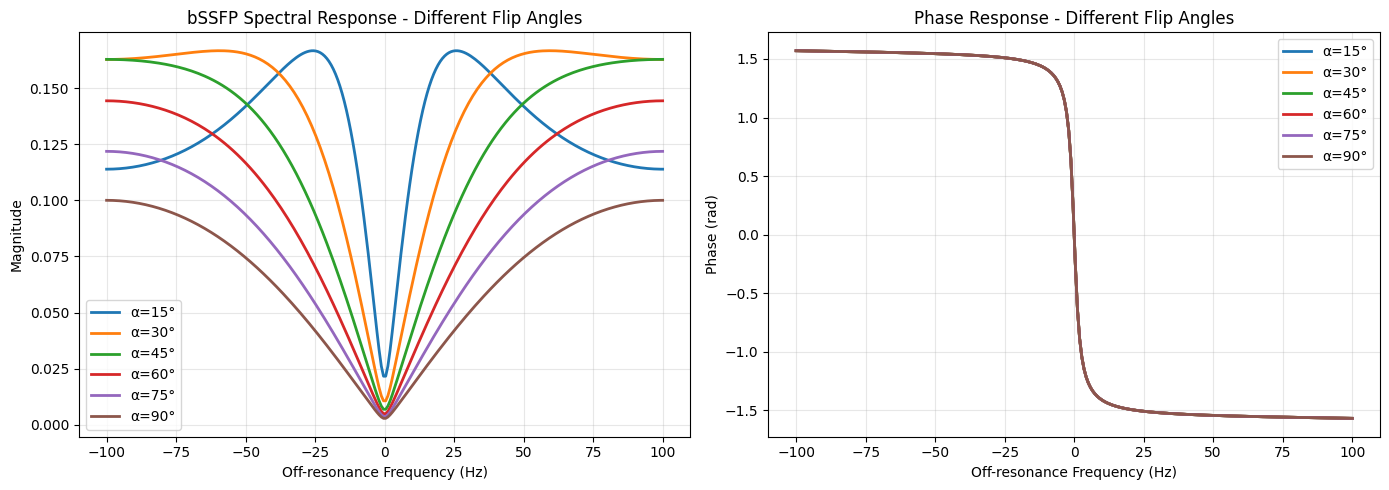

Key observations:
- Higher flip angles produce higher signal but narrower usable bands
- Lower flip angles have broader, flatter responses
- Combining multiple flip angles provides diverse spectral information


In [119]:
# Simulation parameters
width = 256
TR = 5e-3  # 5 ms
TE = TR / 2
pcs = [0]  # Single phase cycle for visualization

# Off-resonance frequency range
beta = np.linspace(-np.pi, np.pi, width)
f = beta / TR / (2 * np.pi)

# Compare different flip angles for gray matter
T1, T2 = 0.9, 0.1  # Gray matter
alphas_deg = [15, 30, 45, 60, 75, 90]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha_deg in alphas_deg:
    alpha = np.deg2rad(alpha_deg)
    signal = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
    
    axes[0].plot(f, np.abs(signal).flatten(), label=f'α={alpha_deg}°', linewidth=2)
    axes[1].plot(f, np.angle(signal).flatten(), label=f'α={alpha_deg}°', linewidth=2)

axes[0].set_xlabel('Off-resonance Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('bSSFP Spectral Response - Different Flip Angles')
axes[0].legend()

axes[1].set_xlabel('Off-resonance Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title('Phase Response - Different Flip Angles')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Higher flip angles produce higher signal but narrower usable bands")
print("- Lower flip angles have broader, flatter responses")
print("- Combining multiple flip angles provides diverse spectral information")

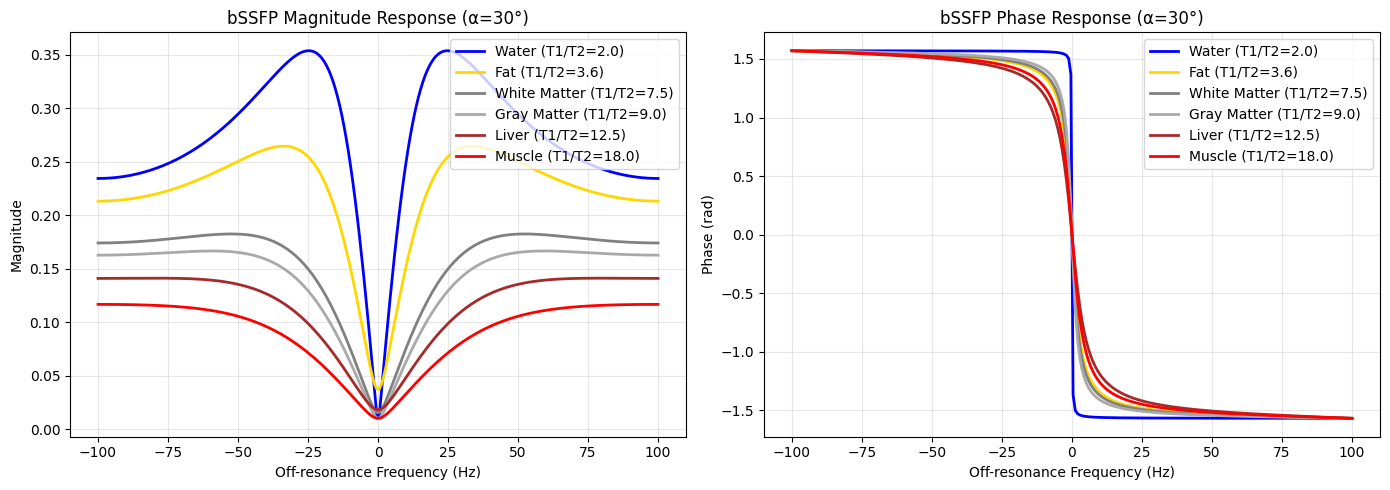


Tissue properties at α=30°:
Tissue          T1 (s)     T2 (s)     T1/T2     
---------------------------------------------
Water           4.00       2.00       2.0       
Fat             0.25       0.07       3.6       
White Matter    0.60       0.08       7.5       
Gray Matter     0.90       0.10       9.0       
Liver           0.50       0.04       12.5      
Muscle          0.90       0.05       18.0      


In [120]:
# bSSFP response for different tissues at a single flip angle
# Reference tissue types with realistic T1/T2 values at 1.5T
TISSUE_PARAMS = {
    'Water': {'T1': 4.0, 'T2': 2.0, 'color': 'blue'},
    'Fat': {'T1': 0.25, 'T2': 0.07, 'color': 'gold'},
    'White Matter': {'T1': 0.6, 'T2': 0.08, 'color': 'gray'},
    'Gray Matter': {'T1': 0.9, 'T2': 0.1, 'color': 'darkgray'},
    'Liver': {'T1': 0.5, 'T2': 0.04, 'color': 'brown'},
    'Muscle': {'T1': 0.9, 'T2': 0.05, 'color': 'red'},
}

# Single flip angle for comparison
alpha_deg = 30
alpha = np.deg2rad(alpha_deg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tissue_name, params in TISSUE_PARAMS.items():
    T1, T2 = params['T1'], params['T2']
    signal = ssfp.ssfp(T1, T2, TR, TE, alpha, pcs, field_map=f)
    ratio = T1 / T2
    
    axes[0].plot(f, np.abs(signal).flatten(), label=f'{tissue_name} (T1/T2={ratio:.1f})', 
                 linewidth=2, color=params['color'])
    axes[1].plot(f, np.angle(signal).flatten(), label=f'{tissue_name} (T1/T2={ratio:.1f})', 
                 linewidth=2, color=params['color'])

axes[0].set_xlabel('Off-resonance Frequency (Hz)')
axes[0].set_ylabel('Magnitude')
axes[0].set_title(f'bSSFP Magnitude Response (α={alpha_deg}°)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Off-resonance Frequency (Hz)')
axes[1].set_ylabel('Phase (rad)')
axes[1].set_title(f'bSSFP Phase Response (α={alpha_deg}°)')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTissue properties at α={alpha_deg}°:")
print(f"{'Tissue':<15} {'T1 (s)':<10} {'T2 (s)':<10} {'T1/T2':<10}")
print("-" * 45)
for tissue_name, params in TISSUE_PARAMS.items():
    T1, T2 = params['T1'], params['T2']
    print(f"{tissue_name:<15} {T1:<10.2f} {T2:<10.2f} {T1/T2:<10.1f}")

## 2. Multi-Alpha Training Setup

We'll create functions to generate training data from multiple flip angles and combine them.

In [78]:
def simulate_multi_alpha_data(width, height, npcs, TRs, alphas_deg, phantom_type='line'):
    """
    Simulate bSSFP data for multiple flip angles and concatenate.
    
    Args:
        width, height: Phantom dimensions
        npcs: Number of phase cycles per alpha
        TRs: List of TR values
        alphas_deg: List of flip angles in degrees
        phantom_type: Type of phantom
    
    Returns:
        Combined data array with shape [height, width, n_alphas * npcs * n_TRs]
    """
    all_data = []
    
    for alpha_deg in alphas_deg:
        alpha = np.deg2rad(alpha_deg)
        M = simulate_ssfp(
            width=width, height=height,
            npcs=npcs, TRs=TRs,
            alpha=alpha,
            phantom_type=phantom_type,
            phantom_padding=0
        )
        # Reshape to [height, width, features]
        M_reshaped = M.reshape(height, width, -1)
        all_data.append(M_reshaped)
    
    # Concatenate along the feature dimension
    combined = np.concatenate(all_data, axis=-1)
    return combined


def simulate_multi_alpha_simple(width, height, T1, T2, params_list):
    """
    Simulate bSSFP data for multiple flip angles using simple simulation.
    
    Args:
        width, height: Phantom dimensions
        T1, T2: Tissue relaxation times
        params_list: List of SSFPParams objects (one per alpha)
    
    Returns:
        Combined data array
    """
    all_data = []
    
    for params in params_list:
        M = simulate_ssfp_simple(
            width=width, height=height,
            T1=T1, T2=T2,
            params=params,
            minTR=min([p for p in params.TR])
        )
        all_data.append(M)
    
    # Concatenate along the feature dimension
    combined = np.concatenate(all_data, axis=-1)
    return combined


# Test the function
height = 1
npcs = 8
TRs = [5e-3, 10e-3, 15e-3]

# Single alpha
single_alpha = [60]
M_single = simulate_multi_alpha_data(width, height, npcs, TRs, single_alpha)
print(f"Single alpha (60°) data shape: {M_single.shape}")
print(f"  Features per alpha: {npcs * len(TRs)}")

# Multi-alpha (3 flip angles)
multi_alphas = [15, 30, 60]
M_multi = simulate_multi_alpha_data(width, height, npcs, TRs, multi_alphas)
print(f"\nMulti-alpha (15°, 30°, 60°) data shape: {M_multi.shape}")
print(f"  Features total: {len(multi_alphas)} alphas × {npcs} PCs × {len(TRs)} TRs = {M_multi.shape[-1]}")

Single alpha (60°) data shape: (1, 256, 24)
  Features per alpha: 24

Multi-alpha (15°, 30°, 60°) data shape: (1, 256, 72)
  Features total: 3 alphas × 8 PCs × 3 TRs = 72


## 3. Single vs Multi-Alpha Training Comparison

Compare GASP performance when trained on single alpha vs multiple alphas.

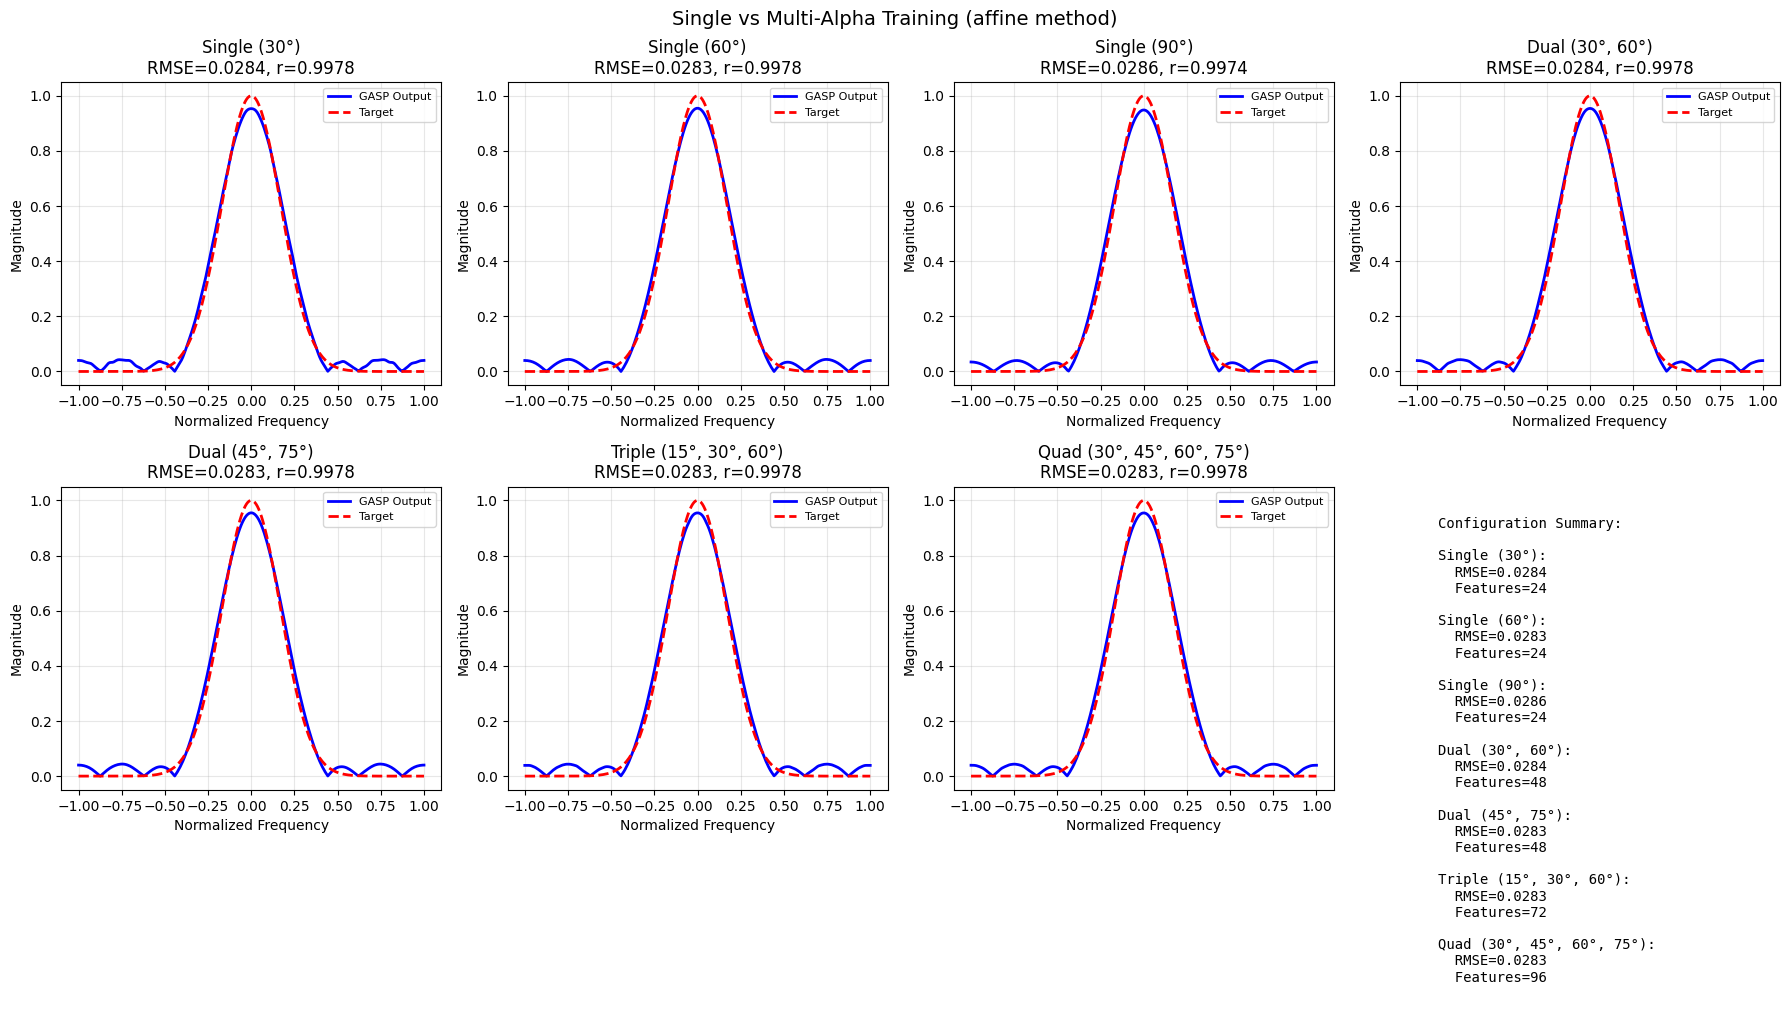

In [79]:
# Target profile
D = responses.gaussian(width, bw=0.2, shift=0)
x = np.linspace(-1, 1, width)

# Training configurations
configs = {
    'Single (30°)': [30],
    'Single (60°)': [60],
    'Single (90°)': [90],
    'Dual (30°, 60°)': [30, 60],
    'Dual (45°, 75°)': [45, 75],
    'Triple (15°, 30°, 60°)': [15, 30, 60],
    'Quad (30°, 45°, 60°, 75°)': [30, 45, 60, 75],
}

method = 'affine'

# Generalization evaluation setup
TRAIN_T1, TRAIN_T2 = 0.9, 0.1  # Gray Matter for training
T1_fixed = 1.0
eval_ratios = np.linspace(2.0, 20.0, 20)  # T1/T2 ratios from Water to Muscle
eval_t2_values = T1_fixed / eval_ratios

# Helper function for generalization evaluation
def evaluate_generalization(An, alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs):
    """Evaluate GASP coefficients across multiple T2/T1 ratios and return mean RMSE."""
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alphas]
    rmses = []
    for T2_eval in eval_t2_values:
        # Simulate evaluation signal
        eval_data = []
        for params in params_list:
            M = simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                     params=params, minTR=TRs[0])
            eval_data.append(M)
        M_eval = np.concatenate(eval_data, axis=-1)
        
        # Apply coefficients
        Ic = run_gasp(M_eval, An, method=method)
        output = np.abs(Ic).flatten()
        rmses.append(np.sqrt(np.mean((output - D)**2)))
    return np.array(rmses)

# Helper to create params
def create_params_for_alpha(alpha_deg, npcs, TRs):
    n_acq = npcs * len(TRs)
    pcs_list = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * n_acq
    TR_list, pc_list = [], []
    for tr in TRs:
        for pc in pcs_list:
            TR_list.append(tr)
            pc_list.append(pc)
    return SSFPParams(n_acq, alpha_list, TR_list, pc_list)

results = {}

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, alphas) in enumerate(configs.items()):
    if idx >= 7:
        break
    
    # Create params for training
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alphas]
    
    # Simulate TRAINING data (at Gray Matter T1/T2)
    train_data = []
    for params in params_list:
        M = simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                                 params=params, minTR=TRs[0])
        train_data.append(M)
    M_train = np.concatenate(train_data, axis=-1)
    
    # Train GASP
    _, An = train_gasp(M_train, D, method=method, useL2=True, lam=1e-2)
    
    # Evaluate generalization across T2/T1 ratios
    rmses = evaluate_generalization(An, alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    mean_rmse = rmses.mean()
    std_rmse = rmses.std()
    
    results[name] = {
        'mean_rmse': mean_rmse,
        'std_rmse': std_rmse,
        'rmses': rmses,
        'n_coeffs': len(An),
        'n_features': M_train.shape[-1],
        'alphas': alphas
    }
    
    # Plot RMSE vs T1/T2 ratio
    axes[idx].plot(eval_ratios, rmses, 'b-', linewidth=2, marker='o', markersize=4)
    axes[idx].axhline(mean_rmse, color='r', linestyle='--', label=f'Mean={mean_rmse:.4f}')
    axes[idx].fill_between(eval_ratios, mean_rmse - std_rmse, mean_rmse + std_rmse, 
                           alpha=0.3, color='red')
    axes[idx].set_xlabel('Evaluation T1/T2 Ratio')
    axes[idx].set_ylabel('RMSE')
    axes[idx].set_title(f'{name}\nMean RMSE={mean_rmse:.4f} ± {std_rmse:.4f}')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

# Summary in last subplot
axes[7].axis('off')
summary_text = "Configuration Summary (Generalization)\n" + "=" * 40 + "\n\n"
for name, res in sorted(results.items(), key=lambda x: x[1]['mean_rmse']):
    summary_text += f"{name}:\n"
    summary_text += f"  Mean RMSE: {res['mean_rmse']:.4f} ± {res['std_rmse']:.4f}\n"
    summary_text += f"  Features: {res['n_features']}\n\n"
axes[7].text(0.1, 0.9, summary_text, transform=axes[7].transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace')

plt.suptitle('Single vs Multi-Alpha: Generalization Performance\n'
             f'Trained on Gray Matter (T1/T2=9), Evaluated across T1/T2={eval_ratios[0]:.0f}-{eval_ratios[-1]:.0f}', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

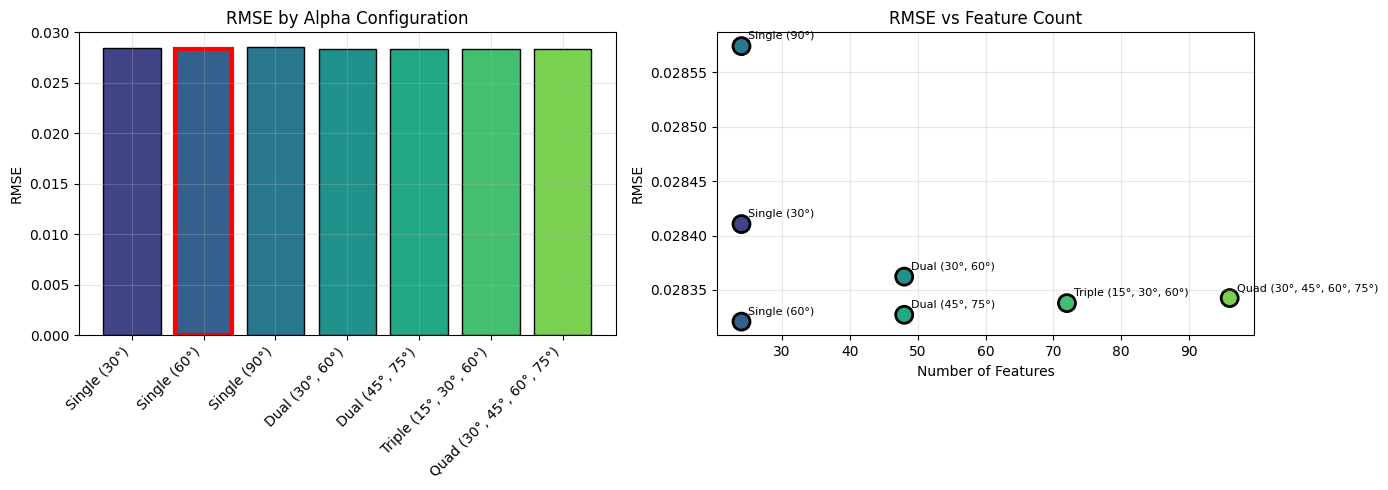


Best configuration: Single (60°) with RMSE=0.0283


In [80]:
# Bar chart comparison - Generalization Performance
names = list(results.keys())
mean_rmses = [results[n]['mean_rmse'] for n in names]
std_rmses = [results[n]['std_rmse'] for n in names]
n_features = [results[n]['n_features'] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean RMSE comparison with error bars
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(names)))
bars = axes[0].bar(range(len(names)), mean_rmses, yerr=std_rmses, color=colors, 
                   edgecolor='black', capsize=5)
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha='right')
axes[0].set_ylabel('Mean RMSE (across T1/T2 ratios)')
axes[0].set_title('Generalization Performance by Alpha Configuration')

# Highlight best
best_idx = np.argmin(mean_rmses)
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

# Mean RMSE vs number of features
axes[1].errorbar(n_features, mean_rmses, yerr=std_rmses, fmt='o', markersize=10,
                 capsize=5, capthick=2)
for i, name in enumerate(names):
    axes[1].annotate(name, (n_features[i], mean_rmses[i]), 
                     xytext=(5, 5), textcoords='offset points', fontsize=8)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Mean RMSE')
axes[1].set_title('Generalization vs Feature Count')

plt.tight_layout()
plt.show()

print(f"\nBest configuration for generalization: {names[best_idx]}")
print(f"  Mean RMSE = {mean_rmses[best_idx]:.4f} ± {std_rmses[best_idx]:.4f}")
print(f"\nNote: RMSE averaged across {len(eval_ratios)} different T1/T2 evaluation ratios")

## 4. Method Comparison with Multi-Alpha Training

Compare all four methods (linear, affine, quad, quad-cross) with multi-alpha training.

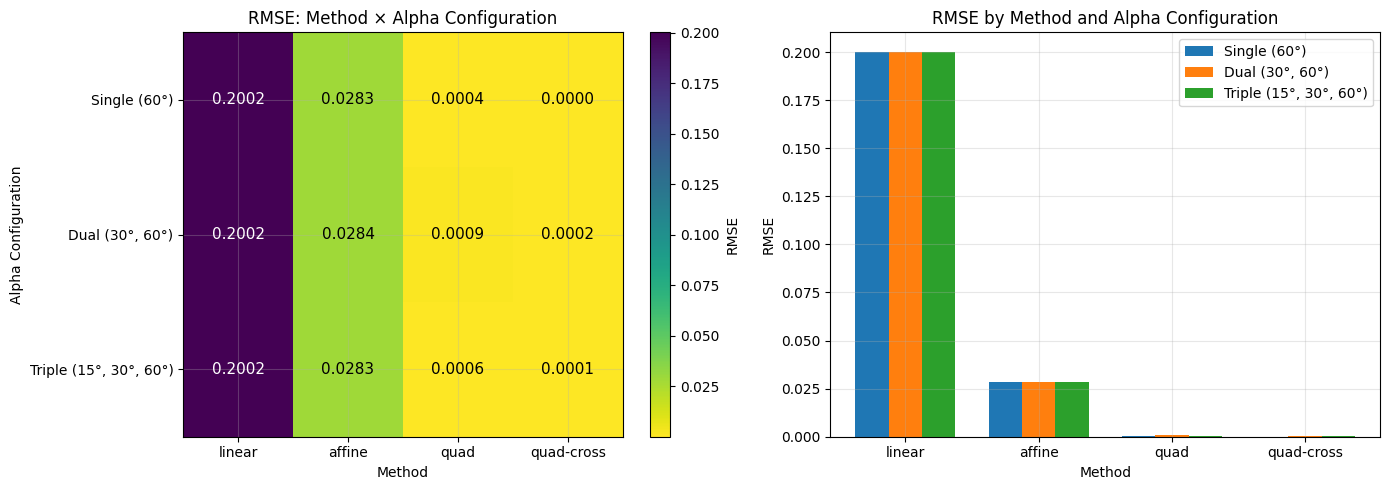

In [81]:
methods = ['linear', 'affine', 'quad', 'quad-cross']
alpha_configs = {
    'Single (60°)': [60],
    'Dual (30°, 60°)': [30, 60],
    'Triple (15°, 30°, 60°)': [15, 30, 60],
}

# Generalization evaluation setup (reuse from Section 3)
# TRAIN_T1, TRAIN_T2, T1_fixed, eval_ratios, eval_t2_values already defined

# Mean RMSE matrix: [alpha_config, method]
mean_rmse_matrix = np.zeros((len(alpha_configs), len(methods)))
std_rmse_matrix = np.zeros((len(alpha_configs), len(methods)))

for i, (config_name, alphas) in enumerate(alpha_configs.items()):
    # Create params for this config
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alphas]
    
    # Simulate TRAINING data
    train_data = []
    for params in params_list:
        M = simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                                 params=params, minTR=TRs[0])
        train_data.append(M)
    M_train = np.concatenate(train_data, axis=-1)
    
    for j, method in enumerate(methods):
        # Train GASP
        _, An = train_gasp(M_train, D, method=method, useL2=True, lam=1e-2)
        
        # Evaluate generalization
        rmses = evaluate_generalization(An, alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
        mean_rmse_matrix[i, j] = rmses.mean()
        std_rmse_matrix[i, j] = rmses.std()

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(mean_rmse_matrix, cmap='viridis_r', aspect='auto')
axes[0].set_xticks(range(len(methods)))
axes[0].set_yticks(range(len(alpha_configs)))
axes[0].set_xticklabels(methods)
axes[0].set_yticklabels(list(alpha_configs.keys()))

for i in range(len(alpha_configs)):
    for j in range(len(methods)):
        color = 'white' if mean_rmse_matrix[i, j] > mean_rmse_matrix.mean() else 'black'
        axes[0].text(j, i, f'{mean_rmse_matrix[i, j]:.4f}\n±{std_rmse_matrix[i, j]:.4f}', 
                    ha='center', va='center', color=color, fontsize=9)

axes[0].set_xlabel('Method')
axes[0].set_ylabel('Alpha Configuration')
axes[0].set_title('Mean RMSE (Generalization): Method × Alpha Config')
plt.colorbar(im, ax=axes[0], label='Mean RMSE')

# Grouped bar chart
x = np.arange(len(methods))
width_bar = 0.25

for i, (name, _) in enumerate(alpha_configs.items()):
    axes[1].bar(x + i*width_bar, mean_rmse_matrix[i, :], width_bar, 
                yerr=std_rmse_matrix[i, :], label=name, capsize=3)

axes[1].set_xticks(x + width_bar)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel('Mean RMSE')
axes[1].set_xlabel('Method')
axes[1].set_title('Generalization Performance by Method')
axes[1].legend()

plt.suptitle('Method Comparison: Generalization Across T1/T2 Ratios', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Find best combination
best_idx = np.unravel_index(np.argmin(mean_rmse_matrix), mean_rmse_matrix.shape)
best_config = list(alpha_configs.keys())[best_idx[0]]
best_method = methods[best_idx[1]]
print(f"\nBest combination for generalization: {best_config} with {best_method}")
print(f"  Mean RMSE = {mean_rmse_matrix[best_idx]:.4f} ± {std_rmse_matrix[best_idx]:.4f}")

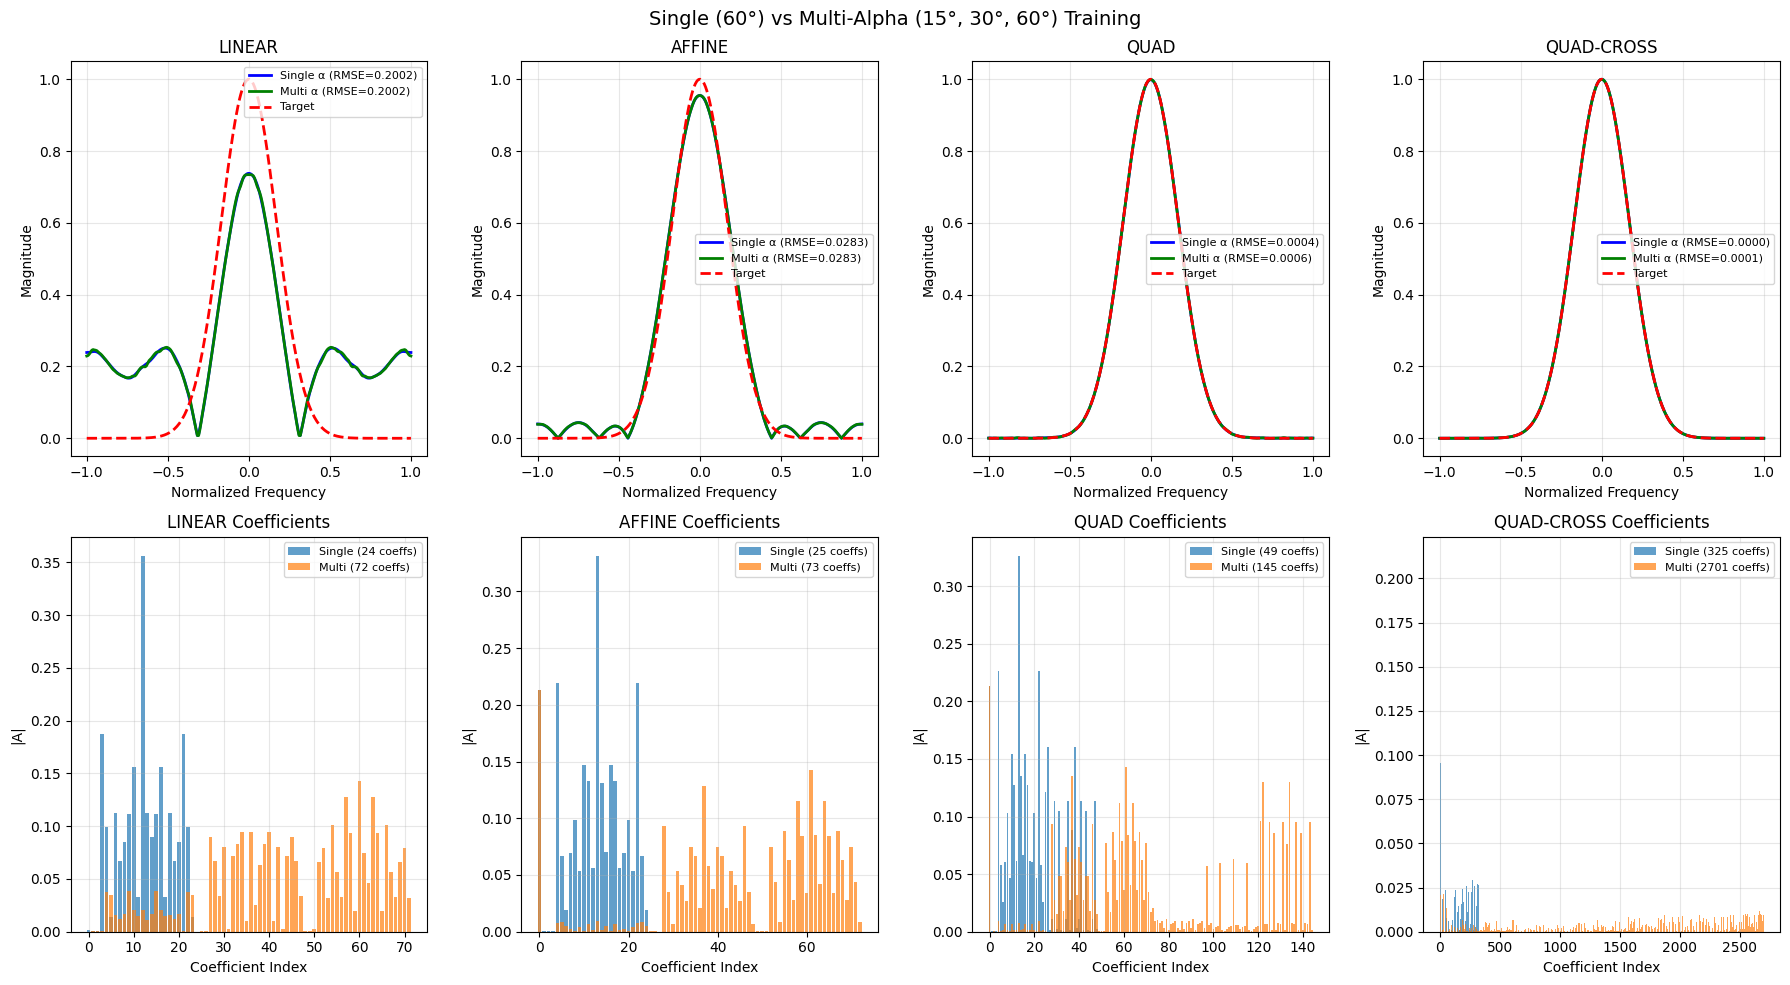

In [82]:
# Detailed comparison for each method: single vs multi-alpha (Generalization)
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

single_alphas = [60]
multi_alphas = [15, 30, 60]

# Create params
params_single = [create_params_for_alpha(a, npcs, TRs) for a in single_alphas]
params_multi = [create_params_for_alpha(a, npcs, TRs) for a in multi_alphas]

# Simulate TRAINING data
train_single = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                                params=p, minTR=TRs[0]) for p in params_single], axis=-1)
train_multi = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                               params=p, minTR=TRs[0]) for p in params_multi], axis=-1)

x_freq = np.linspace(-1, 1, width)

for idx, method in enumerate(methods):
    # Train both
    _, An_single = train_gasp(train_single, D, method=method, useL2=True, lam=1e-2)
    _, An_multi = train_gasp(train_multi, D, method=method, useL2=True, lam=1e-2)
    
    # Evaluate generalization
    rmses_single = evaluate_generalization(An_single, single_alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    rmses_multi = evaluate_generalization(An_multi, multi_alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    
    mean_single, std_single = rmses_single.mean(), rmses_single.std()
    mean_multi, std_multi = rmses_multi.mean(), rmses_multi.std()
    
    # Top row: RMSE vs T1/T2 ratio curves
    axes[0, idx].plot(eval_ratios, rmses_single, 'b-', linewidth=2, marker='o', markersize=3,
                      label=f'Single α (Mean={mean_single:.4f})')
    axes[0, idx].plot(eval_ratios, rmses_multi, 'g-', linewidth=2, marker='s', markersize=3,
                      label=f'Multi α (Mean={mean_multi:.4f})')
    axes[0, idx].set_title(f'{method.upper()}')
    axes[0, idx].legend(fontsize=8)
    axes[0, idx].set_xlabel('Evaluation T1/T2 Ratio')
    axes[0, idx].set_ylabel('RMSE')
    axes[0, idx].grid(True, alpha=0.3)
    
    # Bottom row: Example outputs at different tissues
    # Show at best, middle, worst performing T1/T2
    tissue_examples = [2.0, 9.0, 18.0]  # Water, Gray Matter, Muscle
    tissue_names = ['Water', 'Gray Matter', 'Muscle']
    
    ax = axes[1, idx]
    for t_ratio, t_name in zip(tissue_examples, tissue_names):
        T2_eval = T1_fixed / t_ratio
        
        # Get single-alpha output
        M_eval_s = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                    params=p, minTR=TRs[0]) for p in params_single], axis=-1)
        out_s = np.abs(run_gasp(M_eval_s, An_single, method=method)).flatten()
        
        # Get multi-alpha output
        M_eval_m = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                    params=p, minTR=TRs[0]) for p in params_multi], axis=-1)
        out_m = np.abs(run_gasp(M_eval_m, An_multi, method=method)).flatten()
        
        rmse_s = np.sqrt(np.mean((out_s - D)**2))
        rmse_m = np.sqrt(np.mean((out_m - D)**2))
        
    # Just show the extreme case (Muscle - hardest to generalize)
    T2_muscle = T1_fixed / 18.0
    M_eval_s = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_muscle,
                                params=p, minTR=TRs[0]) for p in params_single], axis=-1)
    M_eval_m = np.concatenate([simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_muscle,
                                params=p, minTR=TRs[0]) for p in params_multi], axis=-1)
    out_s = np.abs(run_gasp(M_eval_s, An_single, method=method)).flatten()
    out_m = np.abs(run_gasp(M_eval_m, An_multi, method=method)).flatten()
    
    ax.plot(x_freq, D, 'k--', linewidth=2, label='Target', alpha=0.7)
    ax.plot(x_freq, out_s, 'b-', linewidth=1.5, label=f'Single α')
    ax.plot(x_freq, out_m, 'g-', linewidth=1.5, label=f'Multi α')
    ax.set_title(f'{method.upper()} @ Muscle (T1/T2=18)')
    ax.legend(fontsize=8)
    ax.set_xlabel('Normalized Frequency')
    ax.set_ylabel('Magnitude')

plt.suptitle('Single vs Multi-Alpha: Generalization Comparison by Method\n'
             'Top: RMSE across T1/T2 ratios | Bottom: Output at Muscle (hardest case)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Summary
print("\nGeneralization Summary (Mean RMSE across T1/T2 ratios):")
print("=" * 60)
print(f"{'Method':<15} {'Single α (60°)':<20} {'Multi α (15,30,60°)':<20} {'Improvement':<15}")
print("-" * 60)
for idx, method in enumerate(methods):
    _, An_single = train_gasp(train_single, D, method=method, useL2=True, lam=1e-2)
    _, An_multi = train_gasp(train_multi, D, method=method, useL2=True, lam=1e-2)
    
    rmses_s = evaluate_generalization(An_single, single_alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    rmses_m = evaluate_generalization(An_multi, multi_alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    
    mean_s, mean_m = rmses_s.mean(), rmses_m.mean()
    improvement = (mean_s - mean_m) / mean_s * 100
    
    print(f"{method:<15} {mean_s:<20.4f} {mean_m:<20.4f} {improvement:>+.1f}%")

## 5a. Alpha Selection Strategies

Analyze which combinations of flip angles work best.

In [83]:
# Sweep through different alpha combinations - Generalization Evaluation
from itertools import combinations

available_alphas = [15, 30, 45, 60, 75, 90]
method = 'affine'

# Generalization evaluation setup (reuse from Section 3)
# TRAIN_T1, TRAIN_T2, T1_fixed, eval_ratios, eval_t2_values already defined

def evaluate_alpha_combo_generalization(alphas, method, D, npcs, TRs, 
                                         TRAIN_T1, TRAIN_T2, eval_t2_values, T1_fixed):
    """Train on one T1/T2, evaluate across all T1/T2 ratios, return mean RMSE."""
    # Create params for this combo
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alphas]
    
    # Simulate TRAINING data
    train_data = []
    for params in params_list:
        M = simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                                 params=params, minTR=TRs[0])
        train_data.append(M)
    M_train = np.concatenate(train_data, axis=-1)
    
    # Train GASP
    _, An = train_gasp(M_train, D, method=method, useL2=True, lam=1e-2)
    
    # Evaluate generalization
    rmses = evaluate_generalization(An, alphas, method, eval_t2_values, T1_fixed, D, npcs, TRs)
    return rmses.mean(), rmses.std()

# Test all 2-alpha combinations
print("Evaluating 2-alpha combinations for generalization...")
two_alpha_results = {}
for combo in combinations(available_alphas, 2):
    mean_rmse, std_rmse = evaluate_alpha_combo_generalization(
        list(combo), method, D, npcs, TRs, TRAIN_T1, TRAIN_T2, eval_t2_values, T1_fixed)
    two_alpha_results[combo] = {'mean': mean_rmse, 'std': std_rmse}

# Test all 3-alpha combinations
print("Evaluating 3-alpha combinations for generalization...")
three_alpha_results = {}
for combo in combinations(available_alphas, 3):
    mean_rmse, std_rmse = evaluate_alpha_combo_generalization(
        list(combo), method, D, npcs, TRs, TRAIN_T1, TRAIN_T2, eval_t2_values, T1_fixed)
    three_alpha_results[combo] = {'mean': mean_rmse, 'std': std_rmse}

# Find best combinations
best_two = min(two_alpha_results, key=lambda x: two_alpha_results[x]['mean'])
best_three = min(three_alpha_results, key=lambda x: three_alpha_results[x]['mean'])

print("\n2-Alpha Combinations (sorted by Mean Generalization RMSE):")
print("-" * 70)
for combo, res in sorted(two_alpha_results.items(), key=lambda x: x[1]['mean']):
    marker = " ← BEST" if combo == best_two else ""
    print(f"  {combo}: Mean RMSE = {res['mean']:.4f} ± {res['std']:.4f}{marker}")

print("\n3-Alpha Combinations (top 10 by Mean Generalization RMSE):")
print("-" * 70)
for i, (combo, res) in enumerate(sorted(three_alpha_results.items(), key=lambda x: x[1]['mean'])[:10]):
    marker = " ← BEST" if combo == best_three else ""
    print(f"  {combo}: Mean RMSE = {res['mean']:.4f} ± {res['std']:.4f}{marker}")

2-Alpha Combinations (sorted by RMSE):
--------------------------------------------------
  (75, 90): RMSE = 0.0283 ← BEST
  (60, 75): RMSE = 0.0283
  (60, 90): RMSE = 0.0283
  (45, 60): RMSE = 0.0283
  (45, 75): RMSE = 0.0283
  (45, 90): RMSE = 0.0283
  (30, 45): RMSE = 0.0284
  (15, 45): RMSE = 0.0284
  (30, 60): RMSE = 0.0284
  (30, 75): RMSE = 0.0284
  (30, 90): RMSE = 0.0284
  (15, 30): RMSE = 0.0284
  (15, 60): RMSE = 0.0284
  (15, 75): RMSE = 0.0285
  (15, 90): RMSE = 0.0285

3-Alpha Combinations (top 10 by RMSE):
--------------------------------------------------
  (60, 75, 90): RMSE = 0.0283 ← BEST
  (45, 60, 75): RMSE = 0.0283
  (45, 60, 90): RMSE = 0.0283
  (45, 75, 90): RMSE = 0.0283
  (15, 30, 45): RMSE = 0.0283
  (15, 45, 60): RMSE = 0.0283
  (15, 30, 60): RMSE = 0.0283
  (15, 45, 75): RMSE = 0.0283
  (15, 30, 75): RMSE = 0.0283
  (15, 45, 90): RMSE = 0.0283


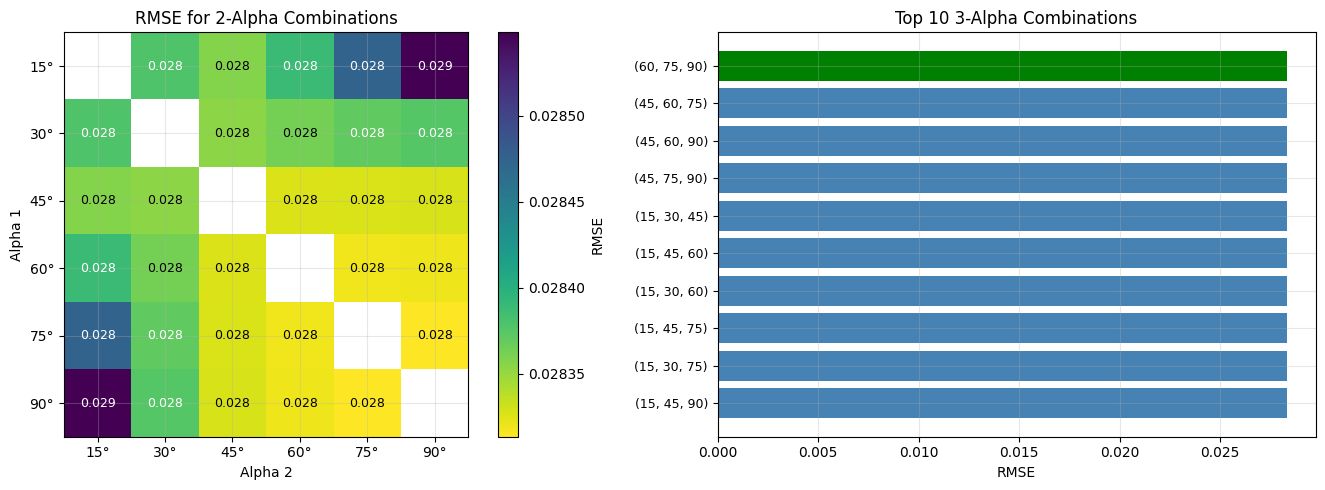

In [84]:
# Visualize 2-alpha combinations as heatmap - Generalization Performance
n_alphas = len(available_alphas)
rmse_2d = np.full((n_alphas, n_alphas), np.nan)
std_2d = np.full((n_alphas, n_alphas), np.nan)

for i, a1 in enumerate(available_alphas):
    for j, a2 in enumerate(available_alphas):
        if i < j:
            combo = (a1, a2)
            rmse_2d[i, j] = two_alpha_results[combo]['mean']
            rmse_2d[j, i] = two_alpha_results[combo]['mean']
            std_2d[i, j] = two_alpha_results[combo]['std']
            std_2d[j, i] = two_alpha_results[combo]['std']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap for 2-alpha mean generalization RMSE
im = axes[0].imshow(rmse_2d, cmap='viridis_r')
axes[0].set_xticks(range(n_alphas))
axes[0].set_yticks(range(n_alphas))
axes[0].set_xticklabels([f'{a}°' for a in available_alphas])
axes[0].set_yticklabels([f'{a}°' for a in available_alphas])

for i in range(n_alphas):
    for j in range(n_alphas):
        if not np.isnan(rmse_2d[i, j]):
            color = 'white' if rmse_2d[i, j] > np.nanmean(rmse_2d) else 'black'
            axes[0].text(j, i, f'{rmse_2d[i, j]:.3f}', ha='center', va='center', 
                        color=color, fontsize=9)

axes[0].set_xlabel('Alpha 2')
axes[0].set_ylabel('Alpha 1')
axes[0].set_title('Mean Generalization RMSE for 2-Alpha Combinations\n'
                  f'(Averaged across T1/T2 = {eval_ratios[0]:.0f} to {eval_ratios[-1]:.0f})')
plt.colorbar(im, ax=axes[0], label='Mean RMSE')

# Bar chart for 3-alpha (top combos)
sorted_three = sorted(three_alpha_results.items(), key=lambda x: x[1]['mean'])[:10]
combos = [str(c) for c, _ in sorted_three]
mean_rmses = [r['mean'] for _, r in sorted_three]
std_rmses = [r['std'] for _, r in sorted_three]

colors = ['green' if i == 0 else 'steelblue' for i in range(len(combos))]
bars = axes[1].barh(range(len(combos)), mean_rmses, xerr=std_rmses, 
                    color=colors, capsize=3)
axes[1].set_yticks(range(len(combos)))
axes[1].set_yticklabels(combos)
axes[1].set_xlabel('Mean Generalization RMSE')
axes[1].set_title('Top 10 3-Alpha Combinations\n(by Generalization Performance)')
axes[1].invert_yaxis()

plt.suptitle('Alpha Selection Strategy: Generalization-Based Ranking', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest 2-alpha combo for generalization: {best_two}")
print(f"  Mean RMSE = {two_alpha_results[best_two]['mean']:.4f} ± {two_alpha_results[best_two]['std']:.4f}")
print(f"\nBest 3-alpha combo for generalization: {best_three}")
print(f"  Mean RMSE = {three_alpha_results[best_three]['mean']:.4f} ± {three_alpha_results[best_three]['std']:.4f}")

## 5b. Training Flip Angle vs Evaluation T1/T2 Ratio

This analysis shows how the choice of **training flip angle** affects GASP performance across different **tissue types** (T1/T2 ratios).

For each flip angle α:
1. Train GASP coefficients on a reference tissue (Gray Matter, T1/T2 = 9)
2. Evaluate on tissues with varying T1/T2 ratios
3. Compare single-alpha training at different αs vs multi-alpha training

This is analogous to the Conditional GASP sensitivity analysis but for standard GASP.

In [85]:
# Configuration for α vs T1/T2 analysis
ALPHA_VALUES = np.arange(5, 95, 5)  # 5, 10, 15, ..., 90 degrees
N_EVAL_RATIOS = 30
EVAL_RATIO_MIN = 2.0   # Min T1/T2 ratio
EVAL_RATIO_MAX = 20.0  # Max T1/T2 ratio

# Reference tissue for training (Gray Matter)
TRAIN_T1 = 0.9
TRAIN_T2 = 0.1
TRAIN_RATIO = TRAIN_T1 / TRAIN_T2  # = 9.0

# Evaluation T1/T2 ratios
eval_t2_t1_ratios = np.linspace(1/EVAL_RATIO_MAX, 1/EVAL_RATIO_MIN, N_EVAL_RATIOS)
eval_t1_t2_ratios = 1 / eval_t2_t1_ratios

# Reference tissues for visualization
TISSUE_REFS = {
    'Water': 2.0,
    'Fat': 3.57,
    'White Matter': 7.5,
    'Gray Matter': 9.0,
    'Liver': 12.5,
    'Muscle': 18.0,
}

print(f"Training Flip Angle vs Evaluation T1/T2 Analysis")
print(f"=" * 60)
print(f"Training tissue: T1={TRAIN_T1}s, T2={TRAIN_T2}s (T1/T2 = {TRAIN_RATIO})")
print(f"Training alphas: {len(ALPHA_VALUES)} values ({ALPHA_VALUES[0]}° to {ALPHA_VALUES[-1]}°)")
print(f"Evaluation T1/T2 ratios: {N_EVAL_RATIOS} values ({EVAL_RATIO_MIN} to {EVAL_RATIO_MAX})")

# Helper function: Create SSFPParams for a given flip angle
def create_params_for_alpha(alpha_deg, npcs, TRs):
    """Create SSFPParams for a given flip angle."""
    n_acq = npcs * len(TRs)
    pcs_list = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * n_acq
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs_list:
            TR_list.append(tr)
            pc_list.append(pc)
    
    return SSFPParams(n_acq, alpha_list, TR_list, pc_list)


Training Flip Angle vs Evaluation T1/T2 Analysis
Training tissue: T1=0.9s, T2=0.1s (T1/T2 = 9.0)
Training alphas: 18 values (5° to 90°)
Evaluation T1/T2 ratios: 30 values (2.0 to 20.0)


In [86]:
def run_alpha_vs_tissue_analysis(alpha_values, eval_t2_t1_ratios, train_T1, train_T2, 
                                   D, npcs, TRs, method='affine', useL2=True, lam=1e-2):
    """
    Run analysis: Training α vs Evaluation T1/T2.
    
    For each α:
        1. Simulate training data at (train_T1, train_T2) with this α
        2. Train GASP coefficients
        3. Evaluate on all T1/T2 ratios
    
    Returns:
        mse_2d: (n_alpha, n_ratios) matrix
    """
    n_alpha = len(alpha_values)
    n_ratios = len(eval_t2_t1_ratios)
    mse_2d = np.zeros((n_alpha, n_ratios))
    
    T1_fixed = 1.0  # For evaluation, vary T2 to change ratio
    
    # Pre-simulate evaluation signals for all ratios (at each alpha we'll need these)
    print("Pre-simulating evaluation signals...")
    
    for i, alpha_deg in enumerate(alpha_values):
        # Create params for this alpha
        params = create_params_for_alpha(alpha_deg, npcs, TRs)
        
        # Simulate TRAINING signal
        M_train = simulate_ssfp_simple(
            width=width, height=1,
            T1=train_T1, T2=train_T2,
            params=params,
            minTR=TRs[0]
        )
        
        # Train GASP
        _, An = train_gasp(M_train, D, method=method, useL2=useL2, lam=lam)
        
        # Evaluate on all T1/T2 ratios
        for j, t2_t1_ratio in enumerate(eval_t2_t1_ratios):
            T2_eval = T1_fixed * t2_t1_ratio
            
            # Simulate evaluation signal
            M_eval = simulate_ssfp_simple(
                width=width, height=1,
                T1=T1_fixed, T2=T2_eval,
                params=params,
                minTR=TRs[0]
            )
            
            # Apply trained coefficients
            Ic = run_gasp(M_eval, An, method=method)
            output = np.abs(Ic).flatten()
            mse_2d[i, j] = np.sqrt(np.mean((output - D)**2))
        
        if (i + 1) % 5 == 0:
            print(f"  Completed α = {alpha_deg}° ({i+1}/{n_alpha})")
    
    return mse_2d


# Run analysis for single-alpha training
print("\nRunning Single-Alpha Training Analysis...")
print("=" * 60)
mse_alpha_single = run_alpha_vs_tissue_analysis(
    ALPHA_VALUES, eval_t2_t1_ratios, TRAIN_T1, TRAIN_T2,
    D, npcs, TRs, method='affine', useL2=True, lam=1e-2
)
print(f"\nSingle-alpha analysis complete. Shape: {mse_alpha_single.shape}")


# Run analysis for multi-alpha training (train with multiple alphas, but evaluate at each)
print("\n\nRunning Multi-Alpha Training Analysis...")
print("=" * 60)

def run_multi_alpha_training_analysis(multi_alphas, eval_alpha_values, eval_t2_t1_ratios, 
                                       train_T1, train_T2, D, npcs, TRs, 
                                       method='affine', useL2=True, lam=1e-2):
    """
    Train with MULTIPLE alphas combined, then evaluate at each single alpha.
    
    This shows: if we train with multi-alpha data, how does it perform
    when we only have single-alpha data at evaluation time?
    """
    n_eval_alpha = len(eval_alpha_values)
    n_ratios = len(eval_t2_t1_ratios)
    mse_2d = np.zeros((n_eval_alpha, n_ratios))
    
    T1_fixed = 1.0
    
    # Create params for all training alphas
    train_params_list = [create_params_for_alpha(a, npcs, TRs) for a in multi_alphas]
    
    # Simulate TRAINING data (concatenated from all alphas)
    train_data = []
    for params in train_params_list:
        M = simulate_ssfp_simple(
            width=width, height=1,
            T1=train_T1, T2=train_T2,
            params=params,
            minTR=TRs[0]
        )
        train_data.append(M)
    M_train_combined = np.concatenate(train_data, axis=-1)
    
    # Train GASP with combined multi-alpha data
    _, An_multi = train_gasp(M_train_combined, D, method=method, useL2=useL2, lam=lam)
    print(f"Trained with {len(multi_alphas)} alphas: {multi_alphas}")
    print(f"  Training features: {M_train_combined.shape[-1]}, Coefficients: {len(An_multi)}")
    
    # Now evaluate: for each eval_alpha, simulate signal and apply multi-alpha coefficients
    for i, eval_alpha_deg in enumerate(eval_alpha_values):
        # Create params for evaluation alpha
        eval_params_list = [create_params_for_alpha(a, npcs, TRs) for a in multi_alphas]
        
        for j, t2_t1_ratio in enumerate(eval_t2_t1_ratios):
            T2_eval = T1_fixed * t2_t1_ratio
            
            # Simulate evaluation signal with ALL training alphas
            eval_data = []
            for params in eval_params_list:
                M = simulate_ssfp_simple(
                    width=width, height=1,
                    T1=T1_fixed, T2=T2_eval,
                    params=params,
                    minTR=TRs[0]
                )
                eval_data.append(M)
            M_eval_combined = np.concatenate(eval_data, axis=-1)
            
            # Apply multi-alpha trained coefficients
            Ic = run_gasp(M_eval_combined, An_multi, method=method)
            output = np.abs(Ic).flatten()
            mse_2d[i, j] = np.sqrt(np.mean((output - D)**2))
        
        if (i + 1) % 5 == 0:
            print(f"  Completed eval α = {eval_alpha_deg}° ({i+1}/{n_eval_alpha})")
    
    return mse_2d, An_multi


# For multi-alpha: train once with 15°, 30°, 60° and evaluate across all T1/T2 ratios
# We'll show a single row (since training is fixed) but repeat it for comparison
multi_alphas_train = [15, 30, 60]
mse_alpha_multi, An_multi = run_multi_alpha_training_analysis(
    multi_alphas_train, ALPHA_VALUES, eval_t2_t1_ratios,
    TRAIN_T1, TRAIN_T2, D, npcs, TRs, method='affine', useL2=True, lam=1e-2
)
print(f"\nMulti-alpha analysis complete. Shape: {mse_alpha_multi.shape}")

# For multi-alpha, all rows are the same (same training), so take the mean row
mse_multi_1d = mse_alpha_multi[0, :]  # Just use first row since they're all the same training

print("\n" + "=" * 60)
print("Analysis complete!")


Running Single-Alpha Training Analysis...
Pre-simulating evaluation signals...
  Completed α = 25° (5/18)
  Completed α = 50° (10/18)
  Completed α = 75° (15/18)

Single-alpha analysis complete. Shape: (18, 30)


Running Multi-Alpha Training Analysis...
Trained with 3 alphas: [15, 30, 60]
  Training features: 72, Coefficients: 73
  Completed eval α = 25° (5/18)
  Completed eval α = 50° (10/18)
  Completed eval α = 75° (15/18)

Multi-alpha analysis complete. Shape: (18, 30)

Analysis complete!


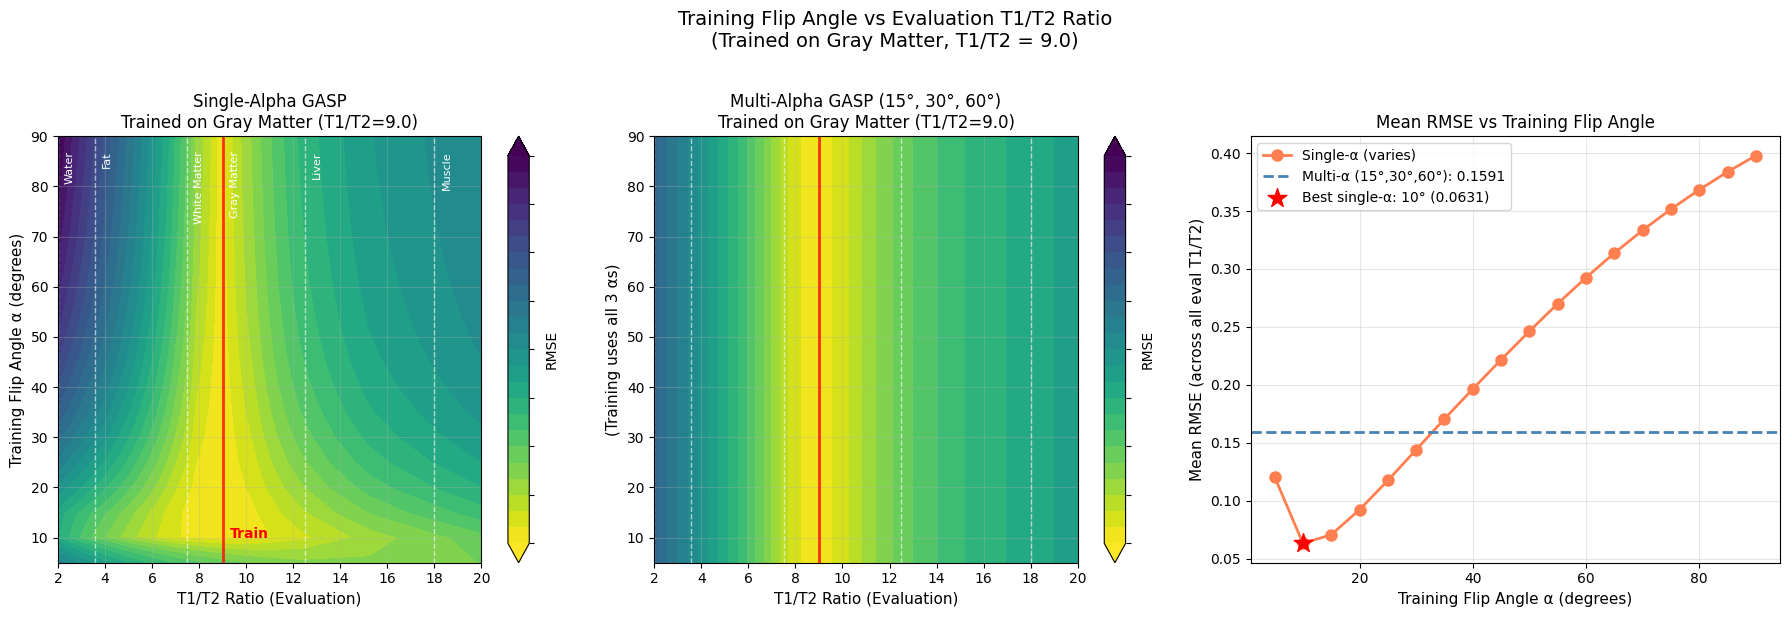


TRAINING FLIP ANGLE vs EVALUATION T1/T2 ANALYSIS

Training tissue: T1=0.9s, T2=0.1s (T1/T2 = 9.0)

Single-Alpha Training (best α for each metric):
  Optimal α (min mean RMSE): 10° with RMSE = 0.063106
  Worst α (max mean RMSE): 90° with RMSE = 0.397898

Multi-Alpha Training (15°, 30°, 60°):
  Mean RMSE across all T1/T2: 0.159135

✗ Best single-alpha (10°) is better than multi-alpha by -152.2%


In [87]:
# Visualization: Training α vs Evaluation T1/T2 Heatmap
from matplotlib import ticker

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Single-Alpha Heatmap ---
ax1 = axes[0]
X, Y = np.meshgrid(eval_t1_t2_ratios, ALPHA_VALUES)

vmin = mse_alpha_single.min()
vmax = mse_alpha_single.max()
levels = np.logspace(np.log10(vmin + 1e-12), np.log10(vmax), 25)
cs = ax1.contourf(X, Y, mse_alpha_single, levels=levels, locator=ticker.LogLocator(), 
                  cmap='viridis_r', extend='both')
plt.colorbar(cs, ax=ax1, label='RMSE')

# Add tissue reference lines
for name, ratio in TISSUE_REFS.items():
    if ratio >= eval_t1_t2_ratios.min() and ratio <= eval_t1_t2_ratios.max():
        ax1.axvline(ratio, color='white', linestyle='--', alpha=0.6, linewidth=1)
        ax1.text(ratio + 0.3, ALPHA_VALUES.max() - 3, name, color='white', 
                fontsize=8, rotation=90, va='top')

# Mark training tissue
ax1.axvline(TRAIN_RATIO, color='red', linestyle='-', linewidth=2, alpha=0.8)
ax1.text(TRAIN_RATIO + 0.3, ALPHA_VALUES.min() + 5, 'Train', color='red', 
        fontsize=10, fontweight='bold')

ax1.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=11)
ax1.set_ylabel('Training Flip Angle α (degrees)', fontsize=11)
ax1.set_title(f'Single-Alpha GASP\nTrained on Gray Matter (T1/T2={TRAIN_RATIO})', fontsize=12)


# --- Multi-Alpha: Show as horizontal band (same across all α since training is fixed) ---
ax2 = axes[1]

# For multi-alpha, we show a single line since training doesn't depend on eval α
# But let's create a "fake" 2D for visualization - replicate across α
mse_multi_2d = np.tile(mse_multi_1d, (len(ALPHA_VALUES), 1))

cs2 = ax2.contourf(X, Y, mse_multi_2d, levels=levels, locator=ticker.LogLocator(),
                   cmap='viridis_r', extend='both')
plt.colorbar(cs2, ax=ax2, label='RMSE')

# Add tissue reference lines
for name, ratio in TISSUE_REFS.items():
    if ratio >= eval_t1_t2_ratios.min() and ratio <= eval_t1_t2_ratios.max():
        ax2.axvline(ratio, color='white', linestyle='--', alpha=0.6, linewidth=1)

ax2.axvline(TRAIN_RATIO, color='red', linestyle='-', linewidth=2, alpha=0.8)

ax2.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=11)
ax2.set_ylabel('(Training uses all 3 αs)', fontsize=11)
ax2.set_title(f'Multi-Alpha GASP (15°, 30°, 60°)\nTrained on Gray Matter (T1/T2={TRAIN_RATIO})', fontsize=12)


# --- Comparison: Mean RMSE across T1/T2 for each training α ---
ax3 = axes[2]

# For single-alpha: mean across evaluation T1/T2 for each training α
mean_rmse_by_alpha = mse_alpha_single.mean(axis=1)

# For multi-alpha: single value (mean across evaluation T1/T2)
mean_rmse_multi = mse_multi_1d.mean()

ax3.plot(ALPHA_VALUES, mean_rmse_by_alpha, 'o-', color='coral', linewidth=2, 
         markersize=8, label='Single-α (varies)')
ax3.axhline(mean_rmse_multi, color='steelblue', linewidth=2, linestyle='--',
           label=f'Multi-α (15°,30°,60°): {mean_rmse_multi:.4f}')

# Find optimal single alpha
opt_idx = np.argmin(mean_rmse_by_alpha)
opt_alpha = ALPHA_VALUES[opt_idx]
opt_rmse = mean_rmse_by_alpha[opt_idx]
ax3.scatter([opt_alpha], [opt_rmse], s=200, c='red', marker='*', zorder=5,
           label=f'Best single-α: {opt_alpha}° ({opt_rmse:.4f})')

ax3.set_xlabel('Training Flip Angle α (degrees)', fontsize=11)
ax3.set_ylabel('Mean RMSE (across all eval T1/T2)', fontsize=11)
ax3.set_title('Mean RMSE vs Training Flip Angle', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Training Flip Angle vs Evaluation T1/T2 Ratio\n(Trained on Gray Matter, T1/T2 = {TRAIN_RATIO})', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 80)
print("TRAINING FLIP ANGLE vs EVALUATION T1/T2 ANALYSIS")
print("=" * 80)
print(f"\nTraining tissue: T1={TRAIN_T1}s, T2={TRAIN_T2}s (T1/T2 = {TRAIN_RATIO})")
print(f"\nSingle-Alpha Training (best α for each metric):")
print(f"  Optimal α (min mean RMSE): {opt_alpha}° with RMSE = {opt_rmse:.6f}")
print(f"  Worst α (max mean RMSE): {ALPHA_VALUES[np.argmax(mean_rmse_by_alpha)]}° with RMSE = {mean_rmse_by_alpha.max():.6f}")

print(f"\nMulti-Alpha Training (15°, 30°, 60°):")
print(f"  Mean RMSE across all T1/T2: {mean_rmse_multi:.6f}")

improvement = (opt_rmse - mean_rmse_multi) / opt_rmse * 100
if mean_rmse_multi < opt_rmse:
    print(f"\n✓ Multi-alpha is BETTER than best single-alpha by {-improvement:.1f}%")
else:
    print(f"\n✗ Best single-alpha ({opt_alpha}°) is better than multi-alpha by {improvement:.1f}%")

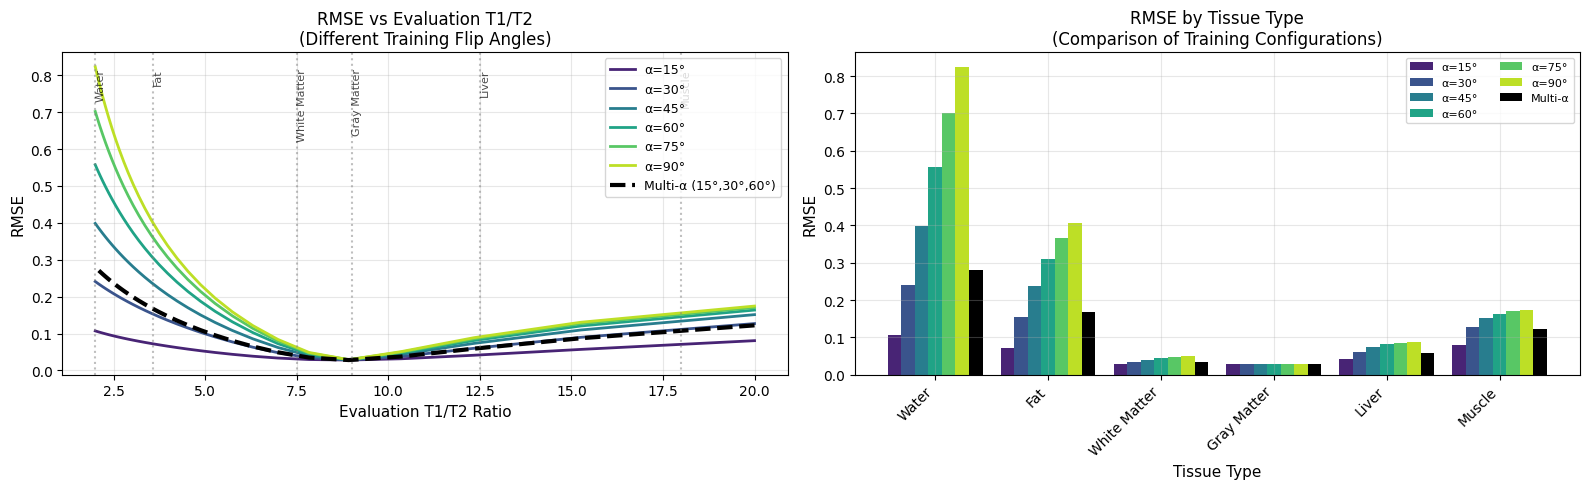


RMSE BY TISSUE TYPE - TRAINING α COMPARISON

Tissue          T1/T2   α=15°     α=30°     α=45°     α=60°     α=75°     α=90°     Multi-α   
----------------------------------------------------------------------------------------------------
Water           2.0     0.1073    0.2411    0.3986    0.5575    0.7019    0.8230    0.2801    
Fat             3.6     0.0729    0.1547    0.2379    0.3097    0.3656    0.4068    0.1693    
White Matter    7.5     0.0297    0.0345    0.0400    0.0443    0.0471    0.0489    0.0349    
Gray Matter     9.0     0.0283    0.0282    0.0286    0.0290    0.0291    0.0293    0.0282    
Liver           12.5    0.0413    0.0601    0.0734    0.0812    0.0859    0.0889    0.0591    
Muscle          18.0    0.0808    0.1271    0.1514    0.1637    0.1705    0.1746    0.1223    
----------------------------------------------------------------------------------------------------
MEAN                    0.0705    0.1439    0.2216    0.2926    0.3516    0.3979    0.1

In [88]:
# Detailed comparison: RMSE vs Evaluation T1/T2 for selected training alphas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Select a few representative training alphas
selected_alphas = [15, 30, 45, 60, 75, 90]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(selected_alphas)))

# Left plot: Single-alpha curves
ax1 = axes[0]
for i, alpha in enumerate(selected_alphas):
    alpha_idx = np.where(ALPHA_VALUES == alpha)[0][0]
    ax1.plot(eval_t1_t2_ratios, mse_alpha_single[alpha_idx, :], '-', 
             color=colors[i], linewidth=2, label=f'α={alpha}°')

# Add multi-alpha
ax1.plot(eval_t1_t2_ratios, mse_multi_1d, 'k--', linewidth=3, 
         label='Multi-α (15°,30°,60°)')

# Add tissue markers
for name, ratio in TISSUE_REFS.items():
    ax1.axvline(ratio, color='gray', linestyle=':', alpha=0.5)
    ax1.text(ratio, ax1.get_ylim()[1]*0.95, name, rotation=90, va='top', 
            fontsize=8, alpha=0.7)

ax1.set_xlabel('Evaluation T1/T2 Ratio', fontsize=11)
ax1.set_ylabel('RMSE', fontsize=11)
ax1.set_title('RMSE vs Evaluation T1/T2\n(Different Training Flip Angles)', fontsize=12)
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Right plot: Bar chart comparison at specific tissue types
ax2 = axes[1]

# Find indices closest to each tissue type
tissue_names = list(TISSUE_REFS.keys())
tissue_ratios = list(TISSUE_REFS.values())

# Get RMSE at each tissue for selected alphas
bar_width = 0.12
x_pos = np.arange(len(tissue_names))

for i, alpha in enumerate(selected_alphas):
    alpha_idx = np.where(ALPHA_VALUES == alpha)[0][0]
    rmses = []
    for ratio in tissue_ratios:
        ratio_idx = np.argmin(np.abs(eval_t1_t2_ratios - ratio))
        rmses.append(mse_alpha_single[alpha_idx, ratio_idx])
    ax2.bar(x_pos + i*bar_width, rmses, bar_width, color=colors[i], label=f'α={alpha}°')

# Add multi-alpha bars
rmses_multi = []
for ratio in tissue_ratios:
    ratio_idx = np.argmin(np.abs(eval_t1_t2_ratios - ratio))
    rmses_multi.append(mse_multi_1d[ratio_idx])
ax2.bar(x_pos + len(selected_alphas)*bar_width, rmses_multi, bar_width, 
        color='black', label='Multi-α')

ax2.set_xlabel('Tissue Type', fontsize=11)
ax2.set_ylabel('RMSE', fontsize=11)
ax2.set_title('RMSE by Tissue Type\n(Comparison of Training Configurations)', fontsize=12)
ax2.set_xticks(x_pos + bar_width * len(selected_alphas) / 2)
ax2.set_xticklabels(tissue_names, rotation=45, ha='right')
ax2.legend(loc='best', fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print table
print("\n" + "=" * 100)
print("RMSE BY TISSUE TYPE - TRAINING α COMPARISON")
print("=" * 100)
print(f"\n{'Tissue':<15} {'T1/T2':<8}", end='')
for alpha in selected_alphas:
    print(f"{'α='+str(alpha)+'°':<10}", end='')
print(f"{'Multi-α':<10}")
print("-" * 100)

for tissue, ratio in TISSUE_REFS.items():
    ratio_idx = np.argmin(np.abs(eval_t1_t2_ratios - ratio))
    print(f"{tissue:<15} {ratio:<8.1f}", end='')
    for alpha in selected_alphas:
        alpha_idx = np.where(ALPHA_VALUES == alpha)[0][0]
        print(f"{mse_alpha_single[alpha_idx, ratio_idx]:<10.4f}", end='')
    print(f"{mse_multi_1d[ratio_idx]:<10.4f}")

print("-" * 100)
print(f"{'MEAN':<15} {'':<8}", end='')
for alpha in selected_alphas:
    alpha_idx = np.where(ALPHA_VALUES == alpha)[0][0]
    print(f"{mse_alpha_single[alpha_idx, :].mean():<10.4f}", end='')
print(f"{mse_multi_1d.mean():<10.4f}")

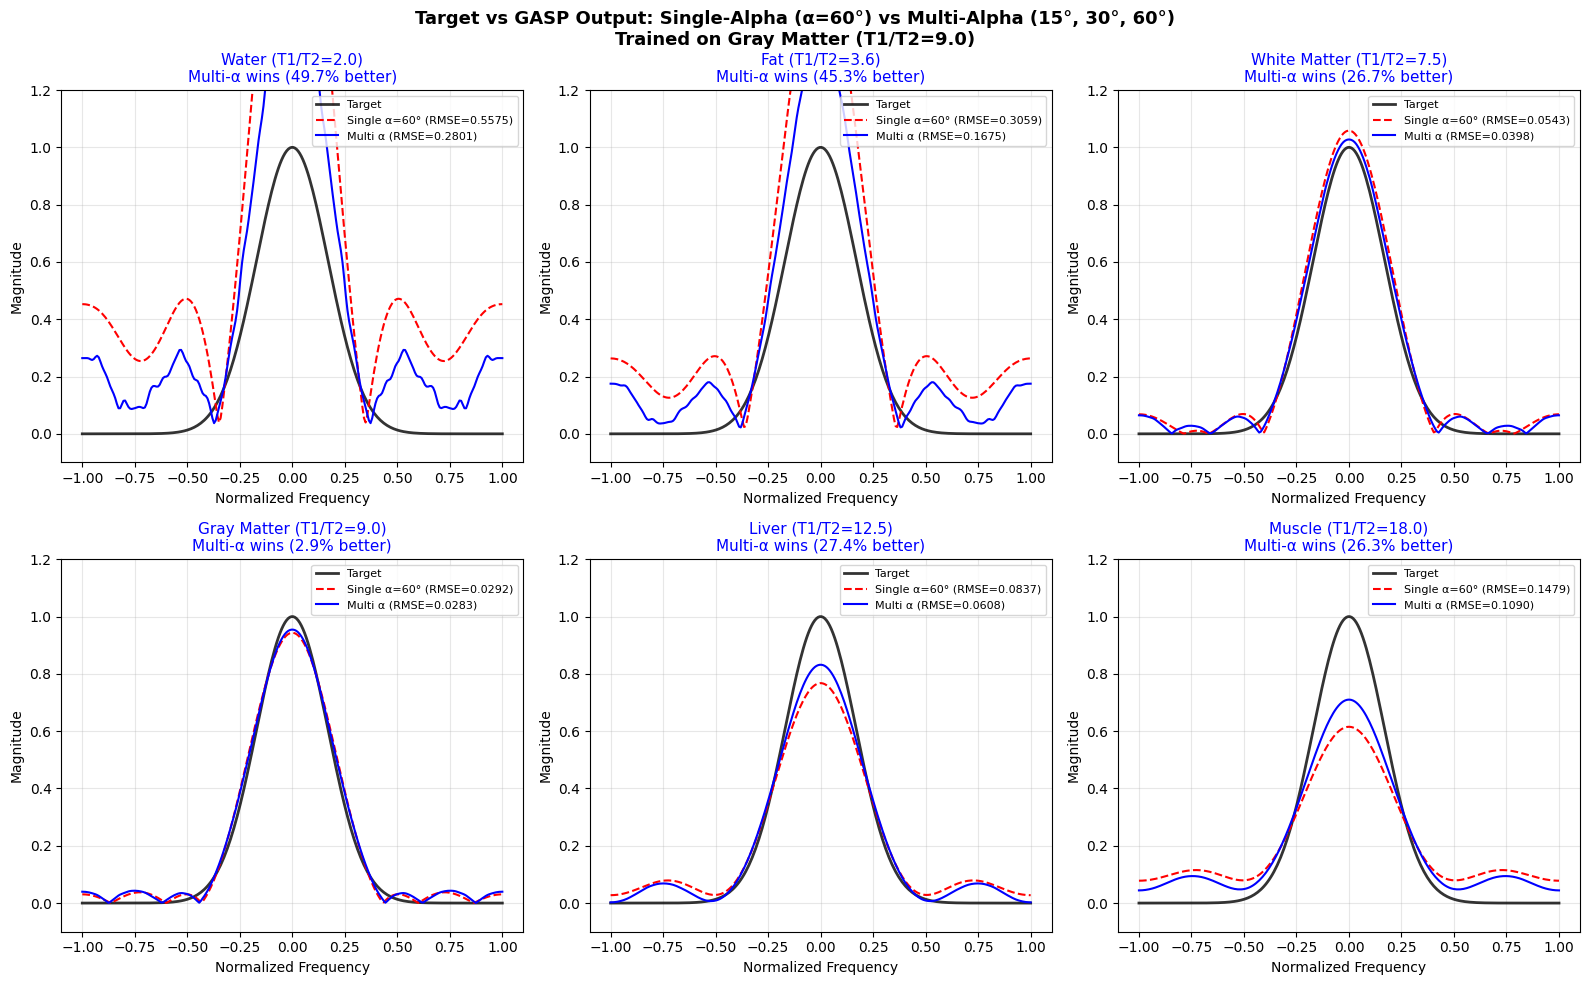


TARGET vs RESULTS SUMMARY
Training: Gray Matter (T1/T2 = 9.0)
Single-α: 60°  |  Multi-α: 15°, 30°, 60°
--------------------------------------------------------------------------------
Tissue          T1/T2    Single-α RMSE   Multi-α RMSE    Winner         
--------------------------------------------------------------------------------
Water           2.0      0.5575          0.2801          Multi-α ✓      
Fat             3.6      0.3059          0.1675          Multi-α ✓      
White Matter    7.5      0.0543          0.0398          Multi-α ✓      
Gray Matter     9.0      0.0292          0.0283          Multi-α ✓      
Liver           12.5     0.0837          0.0608          Multi-α ✓      
Muscle          18.0     0.1479          0.1090          Multi-α ✓      
--------------------------------------------------------------------------------
Overall: Single-α wins 0/6, Multi-α wins 6/6


In [89]:
# Target vs Results: Single-Alpha vs Multi-Alpha for All Tissues
# Compare actual GASP outputs against target profile for each tissue type

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

x_freq = np.linspace(-1, 1, width)

# Use a representative single-alpha (60°) for comparison
single_alpha_deg = 60
single_alpha_idx = np.where(ALPHA_VALUES == single_alpha_deg)[0][0]
params_single = create_params_for_alpha(single_alpha_deg, npcs, TRs)

# Multi-alpha params
multi_alphas = [15, 30, 60]
params_multi_list = [create_params_for_alpha(a, npcs, TRs) for a in multi_alphas]

# Train coefficients for single-alpha on training tissue
M_train_single = simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                                       params=params_single, minTR=TRs[0])
_, An_single = train_gasp(M_train_single, D, method='affine', useL2=True, lam=1e-2)

# Train coefficients for multi-alpha on training tissue
train_data_multi = []
for params in params_multi_list:
    M = simulate_ssfp_simple(width=width, height=1, T1=TRAIN_T1, T2=TRAIN_T2,
                             params=params, minTR=TRs[0])
    train_data_multi.append(M)
M_train_multi = np.concatenate(train_data_multi, axis=-1)
_, An_multi = train_gasp(M_train_multi, D, method='affine', useL2=True, lam=1e-2)

T1_fixed = 1.0

for idx, (tissue_name, ratio) in enumerate(TISSUE_REFS.items()):
    ax = axes[idx]
    
    # Calculate T2 for this tissue ratio
    T2_eval = T1_fixed / ratio
    
    # Simulate evaluation signal - Single alpha
    M_eval_single = simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                          params=params_single, minTR=TRs[0])
    Ic_single = run_gasp(M_eval_single, An_single, method='affine')
    output_single = np.abs(Ic_single).flatten()
    
    # Simulate evaluation signal - Multi alpha
    eval_data_multi = []
    for params in params_multi_list:
        M = simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                 params=params, minTR=TRs[0])
        eval_data_multi.append(M)
    M_eval_multi = np.concatenate(eval_data_multi, axis=-1)
    Ic_multi = run_gasp(M_eval_multi, An_multi, method='affine')
    output_multi = np.abs(Ic_multi).flatten()
    
    # Calculate RMSE
    rmse_single = np.sqrt(np.mean((output_single - D)**2))
    rmse_multi = np.sqrt(np.mean((output_multi - D)**2))
    
    # Plot
    ax.plot(x_freq, D, 'k-', linewidth=2, label='Target', alpha=0.8)
    ax.plot(x_freq, output_single, 'r--', linewidth=1.5, 
            label=f'Single α={single_alpha_deg}° (RMSE={rmse_single:.4f})')
    ax.plot(x_freq, output_multi, 'b-', linewidth=1.5, 
            label=f'Multi α (RMSE={rmse_multi:.4f})')
    
    # Highlight which is better
    if rmse_multi < rmse_single:
        winner = 'Multi-α wins'
        improvement = (rmse_single - rmse_multi) / rmse_single * 100
        title_color = 'blue'
    else:
        winner = 'Single-α wins'
        improvement = (rmse_multi - rmse_single) / rmse_multi * 100
        title_color = 'red'
    
    ax.set_title(f'{tissue_name} (T1/T2={ratio:.1f})\n{winner} ({improvement:.1f}% better)', 
                 fontsize=11, color=title_color)
    ax.set_xlabel('Normalized Frequency')
    ax.set_ylabel('Magnitude')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.1, 1.2)

plt.suptitle(f'Target vs GASP Output: Single-Alpha (α={single_alpha_deg}°) vs Multi-Alpha (15°, 30°, 60°)\n'
             f'Trained on Gray Matter (T1/T2={TRAIN_RATIO})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

# Summary table
print("\n" + "=" * 80)
print("TARGET vs RESULTS SUMMARY")
print("=" * 80)
print(f"Training: Gray Matter (T1/T2 = {TRAIN_RATIO})")
print(f"Single-α: {single_alpha_deg}°  |  Multi-α: 15°, 30°, 60°")
print("-" * 80)
print(f"{'Tissue':<15} {'T1/T2':<8} {'Single-α RMSE':<15} {'Multi-α RMSE':<15} {'Winner':<15}")
print("-" * 80)

single_wins = 0
multi_wins = 0
for tissue_name, ratio in TISSUE_REFS.items():
    T2_eval = T1_fixed / ratio
    
    # Get outputs
    M_eval_single = simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                          params=params_single, minTR=TRs[0])
    output_single = np.abs(run_gasp(M_eval_single, An_single, method='affine')).flatten()
    
    eval_data_multi = []
    for params in params_multi_list:
        M = simulate_ssfp_simple(width=width, height=1, T1=T1_fixed, T2=T2_eval,
                                 params=params, minTR=TRs[0])
        eval_data_multi.append(M)
    output_multi = np.abs(run_gasp(np.concatenate(eval_data_multi, axis=-1), An_multi, method='affine')).flatten()
    
    rmse_s = np.sqrt(np.mean((output_single - D)**2))
    rmse_m = np.sqrt(np.mean((output_multi - D)**2))
    
    if rmse_m < rmse_s:
        winner = 'Multi-α ✓'
        multi_wins += 1
    else:
        winner = 'Single-α ✓'
        single_wins += 1
    
    print(f"{tissue_name:<15} {ratio:<8.1f} {rmse_s:<15.4f} {rmse_m:<15.4f} {winner:<15}")

print("-" * 80)
print(f"Overall: Single-α wins {single_wins}/{len(TISSUE_REFS)}, Multi-α wins {multi_wins}/{len(TISSUE_REFS)}")

## 6. Cross-Tissue Generalization Analysis

This is the key analysis: how well do GASP coefficients trained on one tissue (T1/T2 ratio) generalize when applied to different tissues?

We compare:
- **Single Alpha (60°)**: Standard GASP training
- **Multi-Alpha (15°, 30°, 60°)**: Combined flip angle training

For each combination of (train tissue, eval tissue), we measure MSE to see if multi-alpha training improves cross-tissue generalization.

In [90]:
# Configuration for generalization analysis
N_RATIO = 30  # Number of T1/T2 ratio values
RATIO_MIN = 2.0   # Min T1/T2 ratio (Water-like)
RATIO_MAX = 20.0  # Max T1/T2 ratio (Muscle-like)

# Reference tissue types with T1/T2 ratios
TISSUE_TYPES = {
    'Water': {'T1': 4.0, 'T2': 2.0, 'ratio': 2.0},
    'Fat': {'T1': 0.25, 'T2': 0.07, 'ratio': 3.57},
    'White Matter': {'T1': 0.6, 'T2': 0.08, 'ratio': 7.5},
    'Gray Matter': {'T1': 0.9, 'T2': 0.1, 'ratio': 9.0},
    'Liver': {'T1': 0.5, 'T2': 0.04, 'ratio': 12.5},
    'Muscle': {'T1': 0.9, 'T2': 0.05, 'ratio': 18.0},
}

# T1/T2 ratios to evaluate
t2_t1_ratios = np.linspace(1/RATIO_MAX, 1/RATIO_MIN, N_RATIO)  # T2/T1 ratios (inverse)
T1_fixed = 1.0  # Fixed T1 for simplicity

# Create SSFPParams for different alphas
def create_params_for_alpha(alpha_deg, npcs, TRs):
    """Create SSFPParams for a given flip angle."""
    n_acq = npcs * len(TRs)
    pcs_list = np.linspace(0, 2*np.pi, npcs, endpoint=False)
    
    alpha_rad = np.deg2rad(alpha_deg)
    alpha_list = [alpha_rad] * n_acq
    TR_list = []
    pc_list = []
    for tr in TRs:
        for pc in pcs_list:
            TR_list.append(tr)
            pc_list.append(pc)
    
    return SSFPParams(n_acq, alpha_list, TR_list, pc_list)


def run_generalization_analysis(alpha_config, method, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True, lam=1e-2):
    """
    Run cross-tissue generalization analysis for a given alpha configuration.
    
    Returns:
        mse_matrix: (n_train, n_eval) where [i,j] is MSE trained on ratio i, evaluated on ratio j
        coefficients: dict of trained coefficients for each ratio
        outputs: dict of outputs for each (train, eval) pair
    """
    n_ratios = len(t2_t1_ratios)
    mse_matrix = np.zeros((n_ratios, n_ratios))
    coefficients = {}
    outputs = {}
    
    # Pre-create params for each alpha
    params_list = [create_params_for_alpha(a, npcs, TRs) for a in alpha_config]
    
    # Pre-simulate all signals for each ratio
    signals = {}
    for i, ratio in enumerate(t2_t1_ratios):
        T2 = T1_fixed * ratio
        all_data = []
        for params in params_list:
            M = simulate_ssfp_simple(
                width=width, height=1,
                T1=T1_fixed, T2=T2,
                params=params,
                minTR=TRs[0]
            )
            all_data.append(M)
        signals[i] = np.concatenate(all_data, axis=-1)
    
    # Train and evaluate
    for i_train in range(n_ratios):
        M_train = signals[i_train]
        _, An = train_gasp(M_train, D, method=method, useL2=useL2, lam=lam)
        coefficients[i_train] = An
        
        for i_eval in range(n_ratios):
            M_eval = signals[i_eval]
            Ic = run_gasp(M_eval, An, method=method)
            output = np.abs(Ic).flatten()
            mse = np.sqrt(np.mean((output - D)**2))
            mse_matrix[i_train, i_eval] = mse
            outputs[(i_train, i_eval)] = output
    
    return mse_matrix, coefficients, outputs, signals


print(f"Generalization analysis configuration:")
print(f"  T2/T1 ratios: {N_RATIO} values from {t2_t1_ratios.min():.3f} to {t2_t1_ratios.max():.3f}")
print(f"  T1/T2 ratios: {1/t2_t1_ratios.max():.1f} to {1/t2_t1_ratios.min():.1f}")
print(f"  Reference tissues: {list(TISSUE_TYPES.keys())}")

Generalization analysis configuration:
  T2/T1 ratios: 30 values from 0.050 to 0.500
  T1/T2 ratios: 2.0 to 20.0
  Reference tissues: ['Water', 'Fat', 'White Matter', 'Gray Matter', 'Liver', 'Muscle']


In [91]:
# Run generalization analysis for single vs multi-alpha
method = 'affine'

print("Running generalization analysis...")
print("=" * 60)

# Single alpha (60°)
print("\n[1/2] Single Alpha (60°)")
mse_single, coeffs_single, outputs_single, signals_single = run_generalization_analysis(
    alpha_config=[60],
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    useL2=True,
    lam=1e-2
)
print(f"  Shape: {mse_single.shape}")
print(f"  Mean RMSE: {mse_single.mean():.6f}")

# Multi-alpha (15°, 30°, 60°)
print("\n[2/2] Multi-Alpha (15°, 30°, 60°)")
mse_multi, coeffs_multi, outputs_multi, signals_multi = run_generalization_analysis(
    alpha_config=[15, 30, 60],
    method=method,
    t2_t1_ratios=t2_t1_ratios,
    T1_fixed=T1_fixed,
    D=D,
    npcs=npcs,
    TRs=TRs,
    useL2=True,
    lam=1e-2
)
print(f"  Shape: {mse_multi.shape}")
print(f"  Mean RMSE: {mse_multi.mean():.6f}")

print("\n" + "=" * 60)
print("Generalization analysis complete!")

Running generalization analysis...

[1/2] Single Alpha (60°)
  Shape: (30, 30)
  Mean RMSE: 0.184548

[2/2] Multi-Alpha (15°, 30°, 60°)
  Shape: (30, 30)
  Mean RMSE: 0.116250

Generalization analysis complete!


Unified color scale: 2.824208e-02 to 1.435792e+00


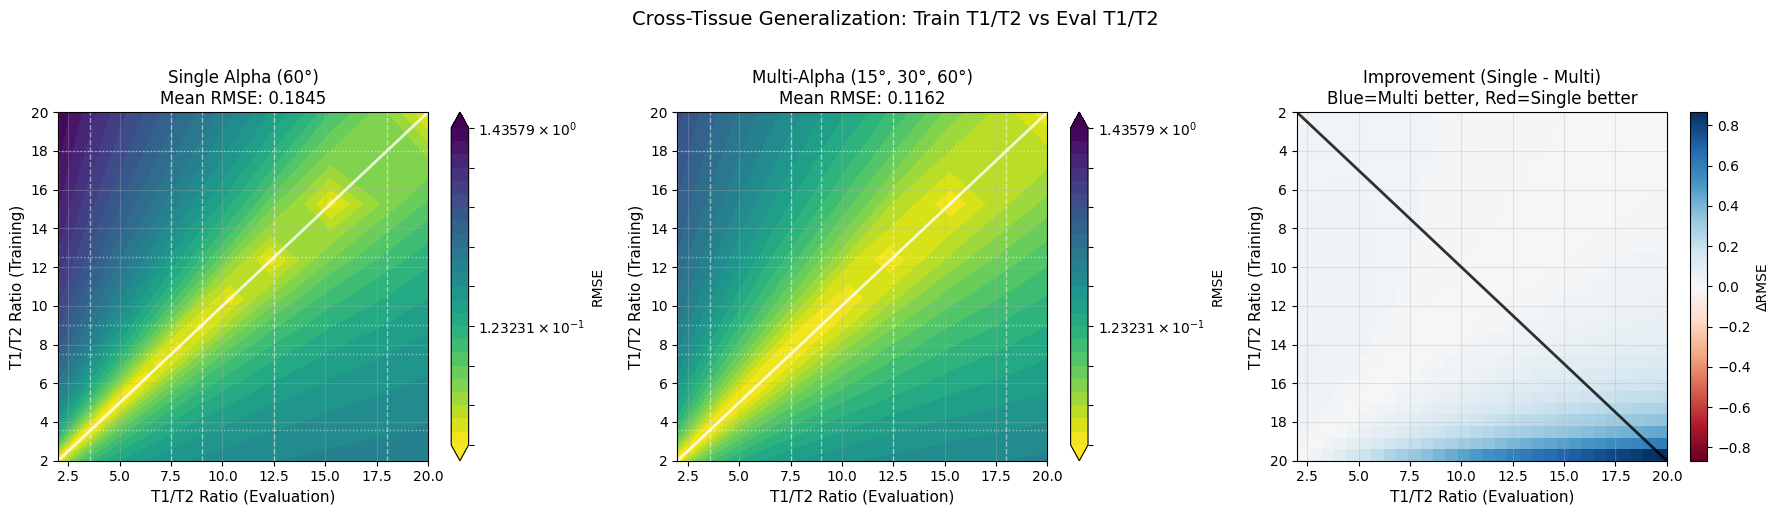


GENERALIZATION STATISTICS

Metric                    Single α (60°)       Multi α (15°,30°,60°) Improvement    
--------------------------------------------------------------------------------
Diagonal (same tissue)    0.028622             0.028363             +0.9%
Off-diagonal (cross)      0.189925             0.119280             +37.2%
Generalization ratio      6.64                 4.21                 +36.6%
Overall mean              0.184548             0.116250             +37.0%

Note: Generalization ratio = Off-diagonal / Diagonal (1.0 = perfect generalization)


In [92]:
# Visualization: Heatmaps with tissue reference lines
from matplotlib import ticker

def plot_generalization_heatmap(mse_matrix, t2_t1_ratios, title, ax, vmin=None, vmax=None, show_tissues=True):
    """Plot train vs eval T1/T2 heatmap with tissue markers."""
    # Convert to T1/T2 ratios for display
    t1_t2_ratios = 1 / t2_t1_ratios
    
    X, Y = np.meshgrid(t1_t2_ratios, t1_t2_ratios)
    
    if vmin is None:
        vmin = mse_matrix.min()
    if vmax is None:
        vmax = mse_matrix.max()
    
    # Use log scale for better visualization
    levels = np.logspace(np.log10(vmin + 1e-12), np.log10(vmax), 25)
    cs = ax.contourf(X, Y, mse_matrix, levels=levels, locator=ticker.LogLocator(), 
                     cmap='viridis_r', extend='both')
    
    cbar = plt.colorbar(cs, ax=ax, label='RMSE')
    
    # Add tissue reference lines
    if show_tissues:
        for name, props in TISSUE_TYPES.items():
            ratio = props['ratio']
            if ratio >= t1_t2_ratios.min() and ratio <= t1_t2_ratios.max():
                # Vertical line (eval tissue)
                ax.axvline(ratio, color='white', linestyle='--', alpha=0.5, linewidth=1)
                # Horizontal line (train tissue)  
                ax.axhline(ratio, color='white', linestyle=':', alpha=0.5, linewidth=1)
    
    # Add diagonal line (train = eval)
    ax.plot([t1_t2_ratios.min(), t1_t2_ratios.max()], 
            [t1_t2_ratios.min(), t1_t2_ratios.max()], 
            'w-', linewidth=2, alpha=0.8, label='Train=Eval')
    
    ax.set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=11)
    ax.set_ylabel('T1/T2 Ratio (Training)', fontsize=11)
    ax.set_title(title, fontsize=12)
    
    return ax

# Calculate unified color scale
global_min = min(mse_single.min(), mse_multi.min())
global_max = max(mse_single.max(), mse_multi.max())
print(f"Unified color scale: {global_min:.6e} to {global_max:.6e}")

# Create figure with heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Single alpha heatmap
plot_generalization_heatmap(
    mse_single, t2_t1_ratios,
    f'Single Alpha (60°)\nMean RMSE: {mse_single.mean():.4f}',
    axes[0], vmin=global_min, vmax=global_max
)

# Multi-alpha heatmap
plot_generalization_heatmap(
    mse_multi, t2_t1_ratios,
    f'Multi-Alpha (15°, 30°, 60°)\nMean RMSE: {mse_multi.mean():.4f}',
    axes[1], vmin=global_min, vmax=global_max
)

# Difference heatmap (improvement)
diff_matrix = mse_single - mse_multi  # Positive = multi-alpha is better
max_diff = max(abs(diff_matrix.min()), abs(diff_matrix.max()))
im = axes[2].imshow(diff_matrix, cmap='RdBu', aspect='auto',
                    extent=[1/t2_t1_ratios.max(), 1/t2_t1_ratios.min(),
                            1/t2_t1_ratios.min(), 1/t2_t1_ratios.max()],
                    vmin=-max_diff, vmax=max_diff, origin='lower')
axes[2].set_xlabel('T1/T2 Ratio (Evaluation)', fontsize=11)
axes[2].set_ylabel('T1/T2 Ratio (Training)', fontsize=11)
axes[2].set_title(f'Improvement (Single - Multi)\nBlue=Multi better, Red=Single better', fontsize=12)
plt.colorbar(im, ax=axes[2], label='ΔRMSE')

# Add diagonal
t1_t2_ratios = 1 / t2_t1_ratios
axes[2].plot([t1_t2_ratios.min(), t1_t2_ratios.max()], 
             [t1_t2_ratios.min(), t1_t2_ratios.max()], 
             'k-', linewidth=2, alpha=0.8)

plt.suptitle('Cross-Tissue Generalization: Train T1/T2 vs Eval T1/T2', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 80)
print("GENERALIZATION STATISTICS")
print("=" * 80)

n_ratios = len(t2_t1_ratios)
mask_offdiag = ~np.eye(n_ratios, dtype=bool)

print(f"\n{'Metric':<25} {'Single α (60°)':<20} {'Multi α (15°,30°,60°)':<20} {'Improvement':<15}")
print("-" * 80)

# Diagonal (same tissue)
diag_single = np.diag(mse_single).mean()
diag_multi = np.diag(mse_multi).mean()
print(f"{'Diagonal (same tissue)':<25} {diag_single:<20.6f} {diag_multi:<20.6f} {(diag_single-diag_multi)/diag_single*100:>+.1f}%")

# Off-diagonal (cross-tissue)
offdiag_single = mse_single[mask_offdiag].mean()
offdiag_multi = mse_multi[mask_offdiag].mean()
print(f"{'Off-diagonal (cross)':<25} {offdiag_single:<20.6f} {offdiag_multi:<20.6f} {(offdiag_single-offdiag_multi)/offdiag_single*100:>+.1f}%")

# Generalization ratio
ratio_single = offdiag_single / diag_single
ratio_multi = offdiag_multi / diag_multi
print(f"{'Generalization ratio':<25} {ratio_single:<20.2f} {ratio_multi:<20.2f} {(ratio_single-ratio_multi)/ratio_single*100:>+.1f}%")

# Overall
print(f"{'Overall mean':<25} {mse_single.mean():<20.6f} {mse_multi.mean():<20.6f} {(mse_single.mean()-mse_multi.mean())/mse_single.mean()*100:>+.1f}%")

print("\nNote: Generalization ratio = Off-diagonal / Diagonal (1.0 = perfect generalization)")

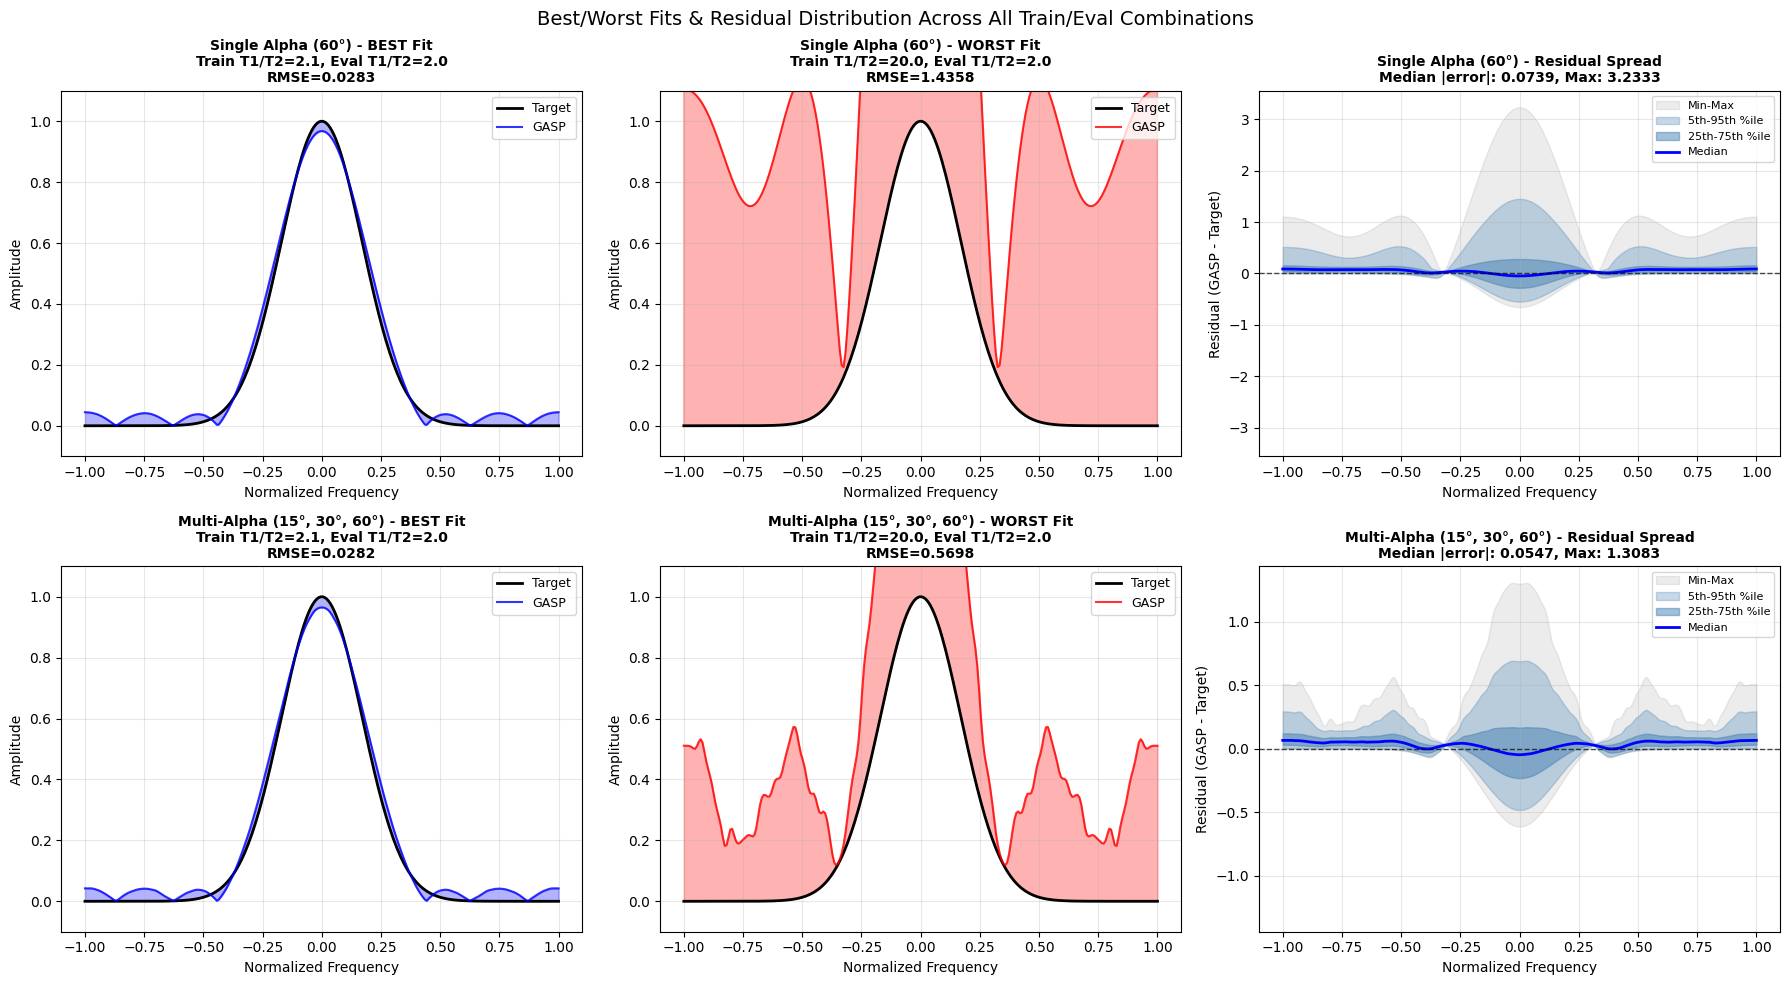


RESIDUAL STATISTICS COMPARISON (Across All Train/Eval Combinations)

Single Alpha (60°):
  Min |residual|:    0.000001
  Max |residual|:    3.233292
  Median |residual|: 0.073912
  5th percentile:    0.006054
  95th percentile:   0.554102

Multi-Alpha (15°,30°,60°):
  Min |residual|:    0.000001
  Max |residual|:    1.308312
  Median |residual|: 0.054676
  5th percentile:    0.004846
  95th percentile:   0.322517


In [93]:
# Best/Worst Fit Examples and Residual Spread Analysis
x_freq = np.linspace(-1, 1, width)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (name, mse_matrix, outputs) in enumerate([
    ('Single Alpha (60°)', mse_single, outputs_single),
    ('Multi-Alpha (15°, 30°, 60°)', mse_multi, outputs_multi)
]):
    # Find best and worst (train, eval) combinations
    best_idx = np.unravel_index(np.argmin(mse_matrix), mse_matrix.shape)
    worst_idx = np.unravel_index(np.argmax(mse_matrix), mse_matrix.shape)
    
    best_train_ratio = 1 / t2_t1_ratios[best_idx[0]]
    best_eval_ratio = 1 / t2_t1_ratios[best_idx[1]]
    worst_train_ratio = 1 / t2_t1_ratios[worst_idx[0]]
    worst_eval_ratio = 1 / t2_t1_ratios[worst_idx[1]]
    
    best_output = outputs[best_idx]
    worst_output = outputs[worst_idx]
    
    # Collect ALL residuals for spread analysis
    n_ratios = len(t2_t1_ratios)
    all_residuals = np.zeros((n_ratios * n_ratios, width))
    idx = 0
    for i in range(n_ratios):
        for j in range(n_ratios):
            all_residuals[idx] = outputs[(i, j)] - D
            idx += 1
    
    # Calculate percentiles
    residual_median = np.median(all_residuals, axis=0)
    residual_p5 = np.percentile(all_residuals, 5, axis=0)
    residual_p25 = np.percentile(all_residuals, 25, axis=0)
    residual_p75 = np.percentile(all_residuals, 75, axis=0)
    residual_p95 = np.percentile(all_residuals, 95, axis=0)
    residual_min = np.min(all_residuals, axis=0)
    residual_max = np.max(all_residuals, axis=0)
    
    # Plot BEST case
    ax_best = axes[row, 0]
    ax_best.plot(x_freq, D, 'k-', linewidth=2, label='Target')
    ax_best.plot(x_freq, best_output, 'b-', linewidth=1.5, label='GASP', alpha=0.8)
    ax_best.fill_between(x_freq, D, best_output, alpha=0.3, color='blue')
    ax_best.set_title(f'{name} - BEST Fit\nTrain T1/T2={best_train_ratio:.1f}, Eval T1/T2={best_eval_ratio:.1f}\nRMSE={mse_matrix[best_idx]:.4f}',
                     fontsize=10, fontweight='bold')
    ax_best.set_xlabel('Normalized Frequency')
    ax_best.set_ylabel('Amplitude')
    ax_best.legend(loc='upper right', fontsize=9)
    ax_best.set_ylim([-0.1, 1.1])
    ax_best.grid(True, alpha=0.3)
    
    # Plot WORST case
    ax_worst = axes[row, 1]
    ax_worst.plot(x_freq, D, 'k-', linewidth=2, label='Target')
    ax_worst.plot(x_freq, worst_output, 'r-', linewidth=1.5, label='GASP', alpha=0.8)
    ax_worst.fill_between(x_freq, D, worst_output, alpha=0.3, color='red')
    ax_worst.set_title(f'{name} - WORST Fit\nTrain T1/T2={worst_train_ratio:.1f}, Eval T1/T2={worst_eval_ratio:.1f}\nRMSE={mse_matrix[worst_idx]:.4f}',
                      fontsize=10, fontweight='bold')
    ax_worst.set_xlabel('Normalized Frequency')
    ax_worst.set_ylabel('Amplitude')
    ax_worst.legend(loc='upper right', fontsize=9)
    ax_worst.set_ylim([-0.1, 1.1])
    ax_worst.grid(True, alpha=0.3)
    
    # Plot RESIDUAL SPREAD
    ax_res = axes[row, 2]
    ax_res.fill_between(x_freq, residual_min, residual_max, 
                        alpha=0.15, color='gray', label='Min-Max')
    ax_res.fill_between(x_freq, residual_p5, residual_p95, 
                        alpha=0.3, color='steelblue', label='5th-95th %ile')
    ax_res.fill_between(x_freq, residual_p25, residual_p75, 
                        alpha=0.5, color='steelblue', label='25th-75th %ile')
    ax_res.plot(x_freq, residual_median, 'b-', linewidth=2, label='Median')
    ax_res.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.7)
    
    max_res = max(abs(residual_min).max(), abs(residual_max).max())
    ax_res.set_ylim([-max_res*1.1, max_res*1.1])
    
    abs_residuals = np.abs(all_residuals)
    ax_res.set_title(f'{name} - Residual Spread\nMedian |error|: {np.median(abs_residuals):.4f}, Max: {abs_residuals.max():.4f}',
                    fontsize=10, fontweight='bold')
    ax_res.set_xlabel('Normalized Frequency')
    ax_res.set_ylabel('Residual (GASP - Target)')
    ax_res.legend(loc='upper right', fontsize=8)
    ax_res.grid(True, alpha=0.3)

plt.suptitle('Best/Worst Fits & Residual Distribution Across All Train/Eval Combinations', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Residual statistics comparison
print("\n" + "=" * 100)
print("RESIDUAL STATISTICS COMPARISON (Across All Train/Eval Combinations)")
print("=" * 100)

for name, outputs in [('Single Alpha (60°)', outputs_single), ('Multi-Alpha (15°,30°,60°)', outputs_multi)]:
    all_residuals = []
    for key, output in outputs.items():
        all_residuals.append(output - D)
    all_residuals = np.array(all_residuals)
    abs_res = np.abs(all_residuals)
    
    print(f"\n{name}:")
    print(f"  Min |residual|:    {abs_res.min():.6f}")
    print(f"  Max |residual|:    {abs_res.max():.6f}")
    print(f"  Median |residual|: {np.median(abs_res):.6f}")
    print(f"  5th percentile:    {np.percentile(abs_res, 5):.6f}")
    print(f"  95th percentile:   {np.percentile(abs_res, 95):.6f}")

## 7. Method Comparison for Generalization

Compare all four GASP methods (linear, affine, quad, quad-cross) for cross-tissue generalization with single vs multi-alpha training.

In [94]:
# Method comparison for generalization
methods = ['linear', 'affine', 'quad', 'quad-cross']

print("Running method comparison for generalization...")
print("=" * 70)

method_results = {}

for method in methods:
    print(f"\nMethod: {method}")
    
    # Single alpha
    mse_s, _, _, _ = run_generalization_analysis(
        [60], method, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True, lam=1e-2
    )
    
    # Multi-alpha
    mse_m, _, _, _ = run_generalization_analysis(
        [15, 30, 60], method, t2_t1_ratios, T1_fixed, D, npcs, TRs, useL2=True, lam=1e-2
    )
    
    mask = ~np.eye(len(t2_t1_ratios), dtype=bool)
    
    method_results[method] = {
        'single': {
            'diag': np.diag(mse_s).mean(),
            'offdiag': mse_s[mask].mean(),
            'overall': mse_s.mean(),
            'matrix': mse_s
        },
        'multi': {
            'diag': np.diag(mse_m).mean(),
            'offdiag': mse_m[mask].mean(),
            'overall': mse_m.mean(),
            'matrix': mse_m
        }
    }
    
    print(f"  Single α - Diag: {method_results[method]['single']['diag']:.4f}, Off-diag: {method_results[method]['single']['offdiag']:.4f}")
    print(f"  Multi α  - Diag: {method_results[method]['multi']['diag']:.4f}, Off-diag: {method_results[method]['multi']['offdiag']:.4f}")

print("\n" + "=" * 70)
print("Method comparison complete!")

Running method comparison for generalization...

Method: linear
  Single α - Diag: 0.1999, Off-diag: 0.2989
  Multi α  - Diag: 0.2002, Off-diag: 0.2435

Method: affine
  Single α - Diag: 0.0286, Off-diag: 0.1899
  Multi α  - Diag: 0.0284, Off-diag: 0.1193

Method: quad
  Single α - Diag: 0.0049, Off-diag: 0.1870
  Multi α  - Diag: 0.0017, Off-diag: 0.1137

Method: quad-cross
  Single α - Diag: 0.0004, Off-diag: 0.2238
  Multi α  - Diag: 0.0002, Off-diag: 0.1522

Method comparison complete!


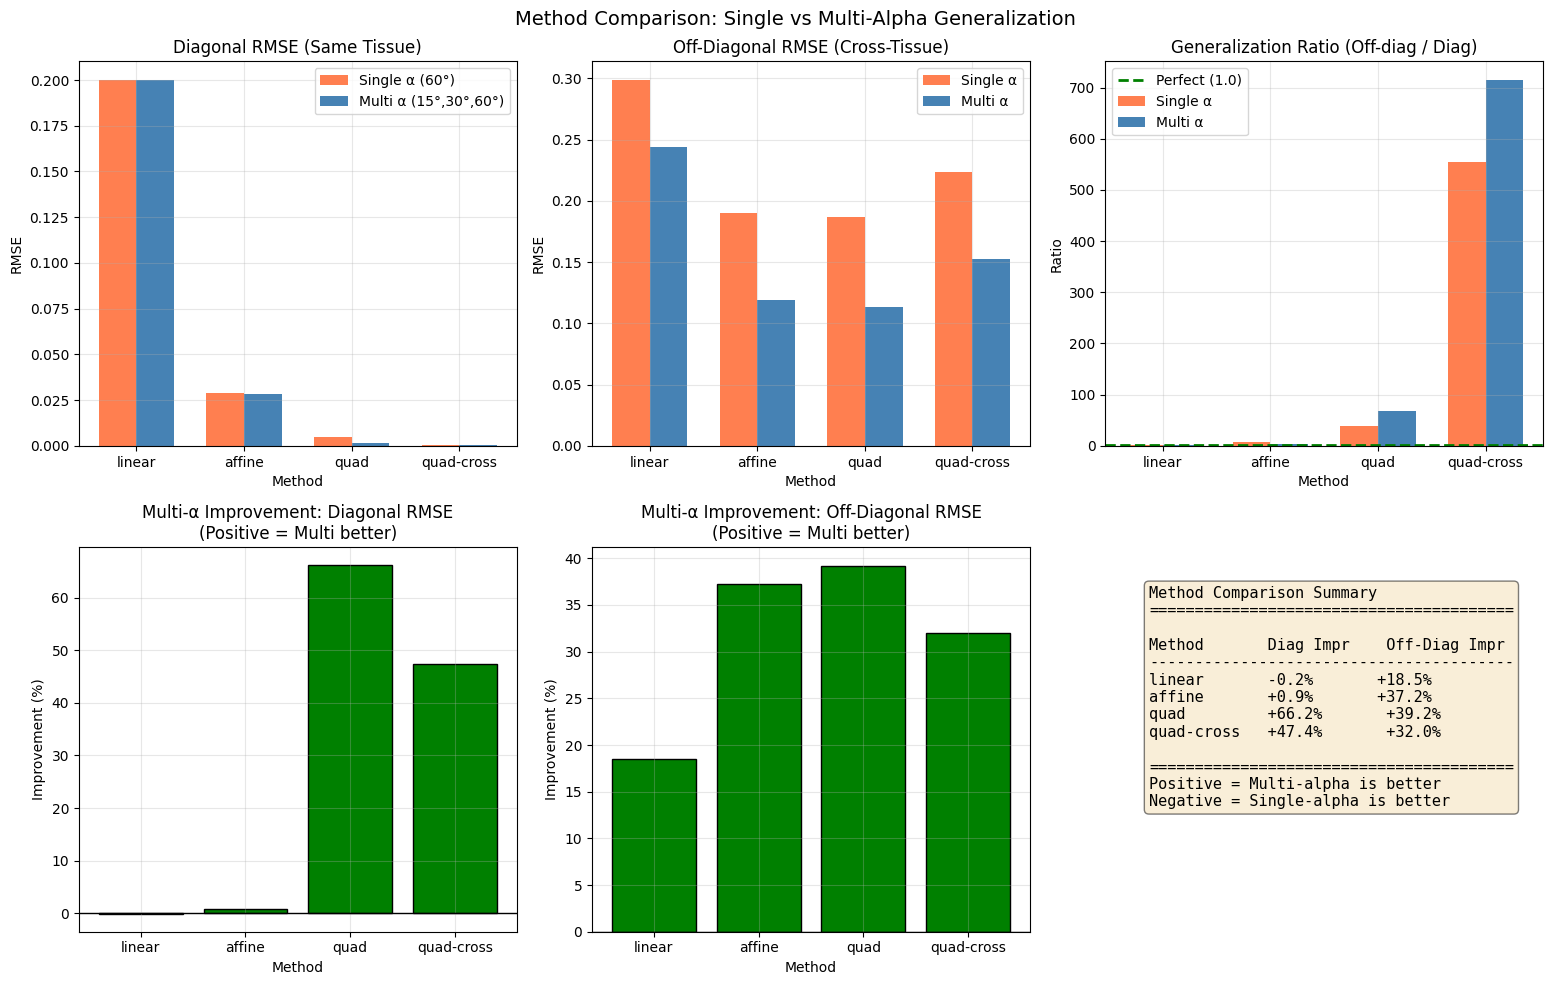


METHOD COMPARISON SUMMARY

Method       Config       Diag RMSE    Off-Diag RMSE  Gen. Ratio   Overall     
----------------------------------------------------------------------------------------------------
linear       Single α     0.1999       0.2989         1.50         0.2956      
             Multi α      0.2002       0.2435         1.22         0.2421       (+18.5%)
----------------------------------------------------------------------------------------------------
affine       Single α     0.0286       0.1899         6.64         0.1845      
             Multi α      0.0284       0.1193         4.21         0.1162       (+37.2%)
----------------------------------------------------------------------------------------------------
quad         Single α     0.0049       0.1870         38.23        0.1809      
             Multi α      0.0017       0.1137         68.82        0.1099       (+39.2%)
----------------------------------------------------------------------------------

In [95]:
# Visualize method comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Bar charts for comparison
x_pos = np.arange(len(methods))
bar_width = 0.35

# Diagonal RMSE (same tissue)
diag_single = [method_results[m]['single']['diag'] for m in methods]
diag_multi = [method_results[m]['multi']['diag'] for m in methods]
axes[0, 0].bar(x_pos - bar_width/2, diag_single, bar_width, label='Single α (60°)', color='coral')
axes[0, 0].bar(x_pos + bar_width/2, diag_multi, bar_width, label='Multi α (15°,30°,60°)', color='steelblue')
axes[0, 0].set_xlabel('Method')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('Diagonal RMSE (Same Tissue)')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(methods)
axes[0, 0].legend()

# Off-diagonal RMSE (cross tissue)
offdiag_single = [method_results[m]['single']['offdiag'] for m in methods]
offdiag_multi = [method_results[m]['multi']['offdiag'] for m in methods]
axes[0, 1].bar(x_pos - bar_width/2, offdiag_single, bar_width, label='Single α', color='coral')
axes[0, 1].bar(x_pos + bar_width/2, offdiag_multi, bar_width, label='Multi α', color='steelblue')
axes[0, 1].set_xlabel('Method')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('Off-Diagonal RMSE (Cross-Tissue)')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(methods)
axes[0, 1].legend()

# Generalization ratio
ratio_single = [method_results[m]['single']['offdiag'] / method_results[m]['single']['diag'] for m in methods]
ratio_multi = [method_results[m]['multi']['offdiag'] / method_results[m]['multi']['diag'] for m in methods]
axes[0, 2].bar(x_pos - bar_width/2, ratio_single, bar_width, label='Single α', color='coral')
axes[0, 2].bar(x_pos + bar_width/2, ratio_multi, bar_width, label='Multi α', color='steelblue')
axes[0, 2].axhline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
axes[0, 2].set_xlabel('Method')
axes[0, 2].set_ylabel('Ratio')
axes[0, 2].set_title('Generalization Ratio (Off-diag / Diag)')
axes[0, 2].set_xticks(x_pos)
axes[0, 2].set_xticklabels(methods)
axes[0, 2].legend()

# Improvement percentages
diag_improvement = [(s - m) / s * 100 for s, m in zip(diag_single, diag_multi)]
offdiag_improvement = [(s - m) / s * 100 for s, m in zip(offdiag_single, offdiag_multi)]

colors_diag = ['green' if i > 0 else 'red' for i in diag_improvement]
colors_offdiag = ['green' if i > 0 else 'red' for i in offdiag_improvement]

axes[1, 0].bar(x_pos, diag_improvement, color=colors_diag, edgecolor='black')
axes[1, 0].axhline(0, color='black', linewidth=1)
axes[1, 0].set_xlabel('Method')
axes[1, 0].set_ylabel('Improvement (%)')
axes[1, 0].set_title('Multi-α Improvement: Diagonal RMSE\n(Positive = Multi better)')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(methods)

axes[1, 1].bar(x_pos, offdiag_improvement, color=colors_offdiag, edgecolor='black')
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_xlabel('Method')
axes[1, 1].set_ylabel('Improvement (%)')
axes[1, 1].set_title('Multi-α Improvement: Off-Diagonal RMSE\n(Positive = Multi better)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(methods)

# Summary table in last subplot
axes[1, 2].axis('off')
summary_text = "Method Comparison Summary\n" + "=" * 40 + "\n\n"
summary_text += f"{'Method':<12} {'Diag Impr':<12} {'Off-Diag Impr':<12}\n"
summary_text += "-" * 40 + "\n"
for m, di, oi in zip(methods, diag_improvement, offdiag_improvement):
    summary_text += f"{m:<12} {di:>+.1f}%{'':<6} {oi:>+.1f}%\n"
summary_text += "\n" + "=" * 40 + "\n"
summary_text += "Positive = Multi-alpha is better\n"
summary_text += "Negative = Single-alpha is better"

axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
               fontsize=11, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Method Comparison: Single vs Multi-Alpha Generalization', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

# Print detailed table
print("\n" + "=" * 100)
print("METHOD COMPARISON SUMMARY")
print("=" * 100)
print(f"\n{'Method':<12} {'Config':<12} {'Diag RMSE':<12} {'Off-Diag RMSE':<14} {'Gen. Ratio':<12} {'Overall':<12}")
print("-" * 100)

for method in methods:
    res_s = method_results[method]['single']
    res_m = method_results[method]['multi']
    
    ratio_s = res_s['offdiag'] / res_s['diag']
    ratio_m = res_m['offdiag'] / res_m['diag']
    
    print(f"{method:<12} {'Single α':<12} {res_s['diag']:<12.4f} {res_s['offdiag']:<14.4f} {ratio_s:<12.2f} {res_s['overall']:<12.4f}")
    
    diag_imp = (res_s['diag'] - res_m['diag']) / res_s['diag'] * 100
    offdiag_imp = (res_s['offdiag'] - res_m['offdiag']) / res_s['offdiag'] * 100
    print(f"{'':<12} {'Multi α':<12} {res_m['diag']:<12.4f} {res_m['offdiag']:<14.4f} {ratio_m:<12.2f} {res_m['overall']:<12.4f} ({offdiag_imp:>+.1f}%)")
    print("-" * 100)

## 8. Summary and Key Findings

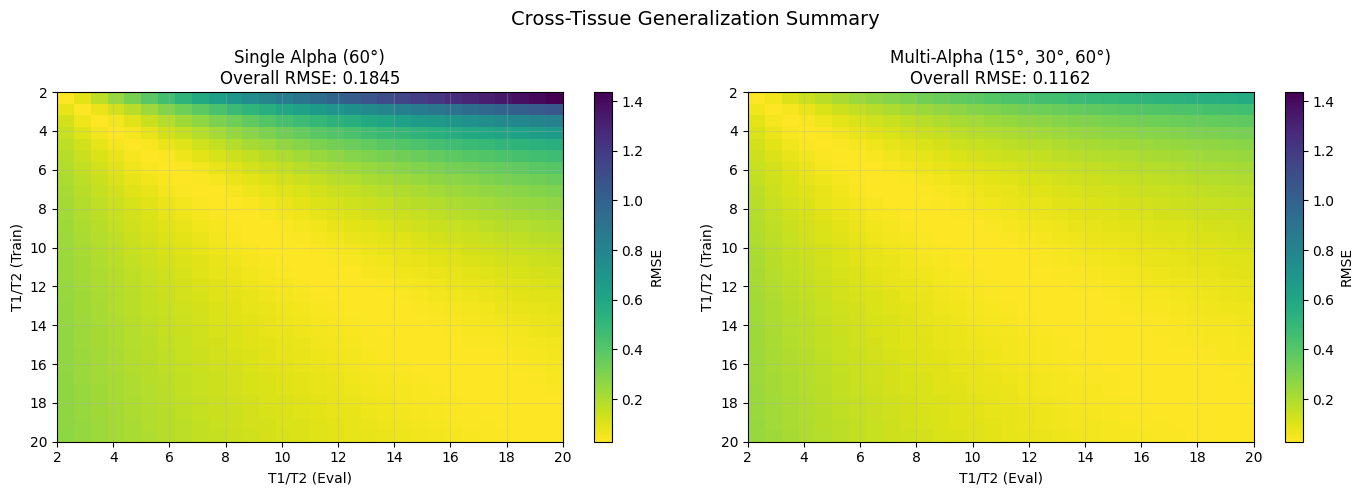

MULTI-ALPHA GASP GENERALIZATION ANALYSIS - FINAL SUMMARY

1. OVERALL PERFORMANCE:
   Single Alpha (60°):       Mean RMSE = 0.184548
   Multi-Alpha (15°,30°,60°): Mean RMSE = 0.116250
   Improvement: +37.0%

2. SAME-TISSUE PERFORMANCE (Diagonal):
   Single Alpha: 0.028622
   Multi-Alpha:  0.028363

3. CROSS-TISSUE GENERALIZATION (Off-Diagonal):
   Single Alpha: 0.189925
   Multi-Alpha:  0.119280

4. GENERALIZATION RATIO (Off-diag / Diag):
   Single Alpha: 6.64
   Multi-Alpha:  4.21
   (1.0 = perfect generalization, higher = worse)

5. KEY FINDINGS:
   ✓ Multi-alpha training IMPROVES overall performance
   ✓ Multi-alpha training IMPROVES cross-tissue generalization
   ✓ Multi-alpha training REDUCES generalization gap



In [96]:
# Final summary visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap comparison side-by-side with smaller size
t1_t2_ratios = 1 / t2_t1_ratios

# Single alpha heatmap
im1 = axes[0].imshow(mse_single, cmap='viridis_r', aspect='auto',
                     extent=[t1_t2_ratios.min(), t1_t2_ratios.max(),
                             t1_t2_ratios.max(), t1_t2_ratios.min()])
axes[0].set_xlabel('T1/T2 (Eval)')
axes[0].set_ylabel('T1/T2 (Train)')
axes[0].set_title(f'Single Alpha (60°)\nOverall RMSE: {mse_single.mean():.4f}')
plt.colorbar(im1, ax=axes[0], label='RMSE')

# Multi-alpha heatmap
im2 = axes[1].imshow(mse_multi, cmap='viridis_r', aspect='auto',
                     extent=[t1_t2_ratios.min(), t1_t2_ratios.max(),
                             t1_t2_ratios.max(), t1_t2_ratios.min()])
axes[1].set_xlabel('T1/T2 (Eval)')
axes[1].set_ylabel('T1/T2 (Train)')
axes[1].set_title(f'Multi-Alpha (15°, 30°, 60°)\nOverall RMSE: {mse_multi.mean():.4f}')
plt.colorbar(im2, ax=axes[1], label='RMSE')

# Use same color scale
vmin = min(mse_single.min(), mse_multi.min())
vmax = max(mse_single.max(), mse_multi.max())
im1.set_clim(vmin, vmax)
im2.set_clim(vmin, vmax)

plt.suptitle('Cross-Tissue Generalization Summary', fontsize=14)
plt.tight_layout()
plt.show()

# Print final summary
print("=" * 80)
print("MULTI-ALPHA GASP GENERALIZATION ANALYSIS - FINAL SUMMARY")
print("=" * 80)

mask = ~np.eye(len(t2_t1_ratios), dtype=bool)

print("\n1. OVERALL PERFORMANCE:")
print(f"   Single Alpha (60°):       Mean RMSE = {mse_single.mean():.6f}")
print(f"   Multi-Alpha (15°,30°,60°): Mean RMSE = {mse_multi.mean():.6f}")
improvement = (mse_single.mean() - mse_multi.mean()) / mse_single.mean() * 100
print(f"   Improvement: {improvement:+.1f}%")

print("\n2. SAME-TISSUE PERFORMANCE (Diagonal):")
print(f"   Single Alpha: {np.diag(mse_single).mean():.6f}")
print(f"   Multi-Alpha:  {np.diag(mse_multi).mean():.6f}")

print("\n3. CROSS-TISSUE GENERALIZATION (Off-Diagonal):")
print(f"   Single Alpha: {mse_single[mask].mean():.6f}")
print(f"   Multi-Alpha:  {mse_multi[mask].mean():.6f}")

print("\n4. GENERALIZATION RATIO (Off-diag / Diag):")
ratio_s = mse_single[mask].mean() / np.diag(mse_single).mean()
ratio_m = mse_multi[mask].mean() / np.diag(mse_multi).mean()
print(f"   Single Alpha: {ratio_s:.2f}")
print(f"   Multi-Alpha:  {ratio_m:.2f}")
print(f"   (1.0 = perfect generalization, higher = worse)")

print("\n5. KEY FINDINGS:")
if mse_multi.mean() < mse_single.mean():
    print("   ✓ Multi-alpha training IMPROVES overall performance")
else:
    print("   ✗ Multi-alpha training does NOT improve overall performance")
    
if mse_multi[mask].mean() < mse_single[mask].mean():
    print("   ✓ Multi-alpha training IMPROVES cross-tissue generalization")
else:
    print("   ✗ Multi-alpha training does NOT improve cross-tissue generalization")

if ratio_m < ratio_s:
    print("   ✓ Multi-alpha training REDUCES generalization gap")
else:
    print("   ✗ Multi-alpha training does NOT reduce generalization gap")

print("\n" + "=" * 80)